Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

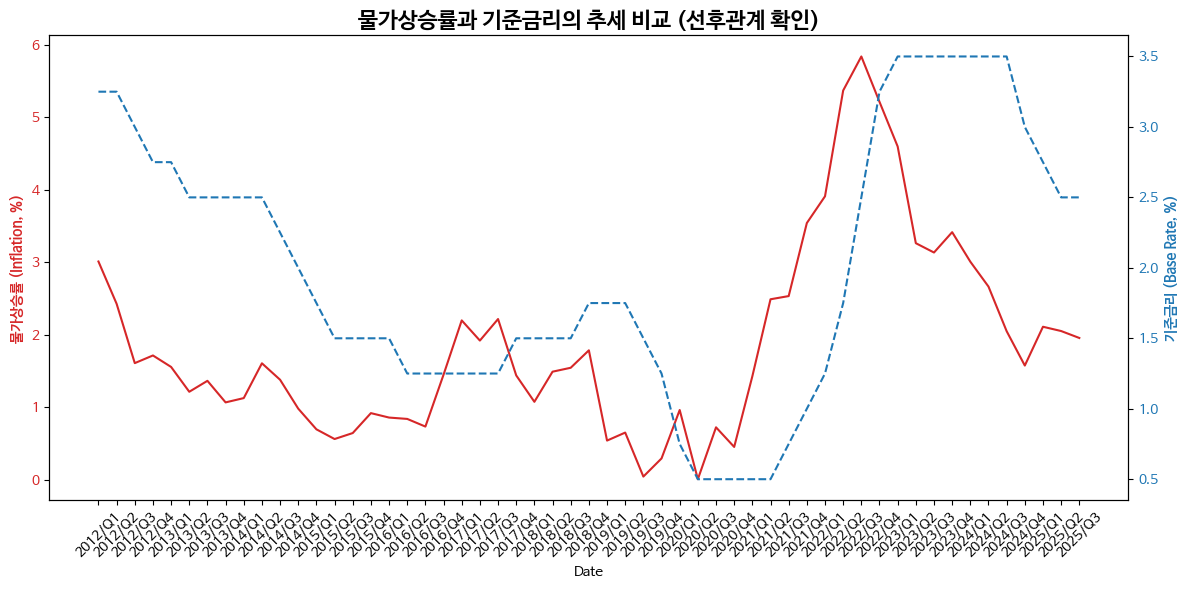

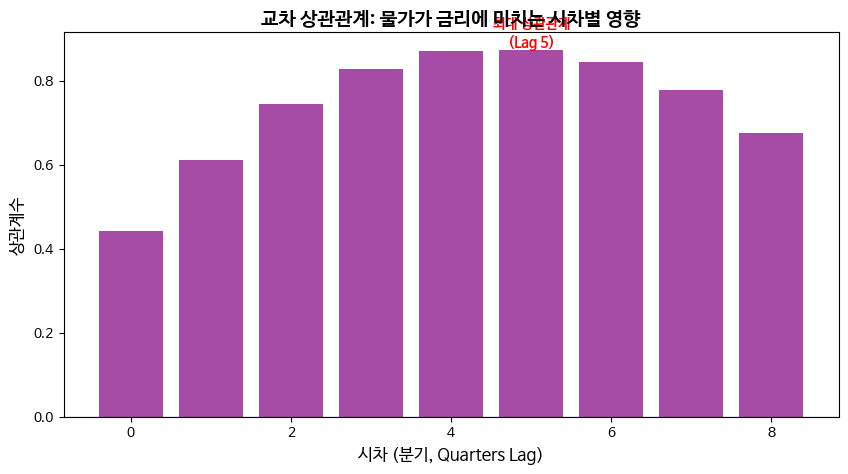


[분석 결과 1: 교차 상관관계]
물가상승률이 변동하고 나서 약 5분기(15개월) 후에 금리와의 상관성이 가장 높습니다.

[분석 결과 2: 통계적 인과관계 검정 (Granger Causality)]
가설 검정: p-value가 0.05보다 작으면 '인과관계가 있다'고 판단합니다.

▶ 검정 1: 물가가 오르면 -> 금리가 변하는가? (Inflation causes Rate?)
Lag 1 (3개월 후): p-value = 0.0000 => ★ 유의미함 (인과관계 있음)
Lag 2 (6개월 후): p-value = 0.0000 => ★ 유의미함 (인과관계 있음)
Lag 3 (9개월 후): p-value = 0.0000 => ★ 유의미함 (인과관계 있음)
Lag 4 (12개월 후): p-value = 0.0000 => ★ 유의미함 (인과관계 있음)

▶ 검정 2: 금리가 변하면 -> 물가가 변하는가? (Rate causes Inflation?)
Lag 1 (3개월 후): p-value = 0.0007 => ★ 유의미함 (인과관계 있음)
Lag 2 (6개월 후): p-value = 0.0094 => ★ 유의미함 (인과관계 있음)
Lag 3 (9개월 후): p-value = 0.1331 => 유의미하지 않음
Lag 4 (12개월 후): p-value = 0.2065 => 유의미하지 않음


In [ ]:

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import sys
import subprocess
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, ccf

warnings.filterwarnings("ignore")


def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False
    else:
        print("폰트 설치 필요")

set_korean_font()


file_paths = {
    'base_rate': 'base_rate.csv',
    'cpi': 'cpi.csv'
}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro_quarterly(df, col_name):
    if df is None: return None

    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:

        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]

    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)


    df_val['Year'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_val['Quarter'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_val = df_val.sort_values(['Year', 'Quarter']).reset_index(drop=True)
    return df_val


print("데이터 로딩 및 분석 준비...")
df_base = preprocess_macro_quarterly(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
df_cpi = preprocess_macro_quarterly(read_csv_safe(file_paths['cpi']), 'CPI')

if df_base is not None and df_cpi is not None:

    df = pd.merge(df_base, df_cpi, on=['Date', 'Year', 'Quarter'], how='inner')



    df['Inflation'] = df['CPI'].pct_change(4) * 100


    df_clean = df.dropna().reset_index(drop=True)


    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('물가상승률 (Inflation, %)', color=color, fontweight='bold')
    ax1.plot(df_clean['Date'], df_clean['Inflation'], color=color, label='물가상승률(CPI YoY)')
    ax1.tick_params(axis='y', labelcolor=color)
    plt.xticks(rotation=45)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('기준금리 (Base Rate, %)', color=color, fontweight='bold')
    ax2.plot(df_clean['Date'], df_clean['Base_Rate'], color=color, linestyle='--', label='기준금리')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('물가상승률과 기준금리의 추세 비교 (선후관계 확인)', fontsize=16, fontweight='bold')
    fig.tight_layout()
    plt.show()



    lags = 8 # 8분기(2년)까지 확인
    inflation_data = df_clean['Inflation']
    rate_data = df_clean['Base_Rate']


    x_corr = [df_clean['Inflation'].corr(df_clean['Base_Rate'].shift(-i)) for i in range(lags+1)]

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(x_corr)), x_corr, color='purple', alpha=0.7)
    plt.title('교차 상관관계: 물가가 금리에 미치는 시차별 영향', fontsize=14, fontweight='bold')
    plt.xlabel('시차 (분기, Quarters Lag)', fontsize=12)
    plt.ylabel('상관계수', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8)

    max_corr_lag = np.argmax(np.abs(x_corr))
    plt.text(max_corr_lag, x_corr[max_corr_lag], f'최대 상관관계\n(Lag {max_corr_lag})',
             ha='center', va='bottom', color='red', fontweight='bold')
    plt.show()

    print(f"\n[분석 결과 1: 교차 상관관계]")
    print(f"물가상승률이 변동하고 나서 약 {max_corr_lag}분기({max_corr_lag*3}개월) 후에 금리와의 상관성이 가장 높습니다.")



    print(f"\n{'='*50}")
    print(f"[분석 결과 2: 통계적 인과관계 검정 (Granger Causality)]")
    print(f"가설 검정: p-value가 0.05보다 작으면 '인과관계가 있다'고 판단합니다.")
    print(f"{'='*50}")


    print("\n▶ 검정 1: 물가가 오르면 -> 금리가 변하는가? (Inflation causes Rate?)")
    res_1 = grangercausalitytests(df_clean[['Base_Rate', 'Inflation']], maxlag=[1, 2, 3, 4], verbose=False)

    for lag in [1, 2, 3, 4]:
        p_val = res_1[lag][0]['ssr_chi2test'][1]
        is_cause = "★ 유의미함 (인과관계 있음)" if p_val < 0.05 else "유의미하지 않음"
        print(f"Lag {lag} ({(lag)*3}개월 후): p-value = {p_val:.4f} => {is_cause}")


    print("\n▶ 검정 2: 금리가 변하면 -> 물가가 변하는가? (Rate causes Inflation?)")
    res_2 = grangercausalitytests(df_clean[['Inflation', 'Base_Rate']], maxlag=[1, 2, 3, 4], verbose=False)

    for lag in [1, 2, 3, 4]:
        p_val = res_2[lag][0]['ssr_chi2test'][1]
        is_cause = "★ 유의미함 (인과관계 있음)" if p_val < 0.05 else "유의미하지 않음"
        print(f"Lag {lag} ({(lag)*3}개월 후): p-value = {p_val:.4f} => {is_cause}")

else:
    print("데이터 로딩 실패")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

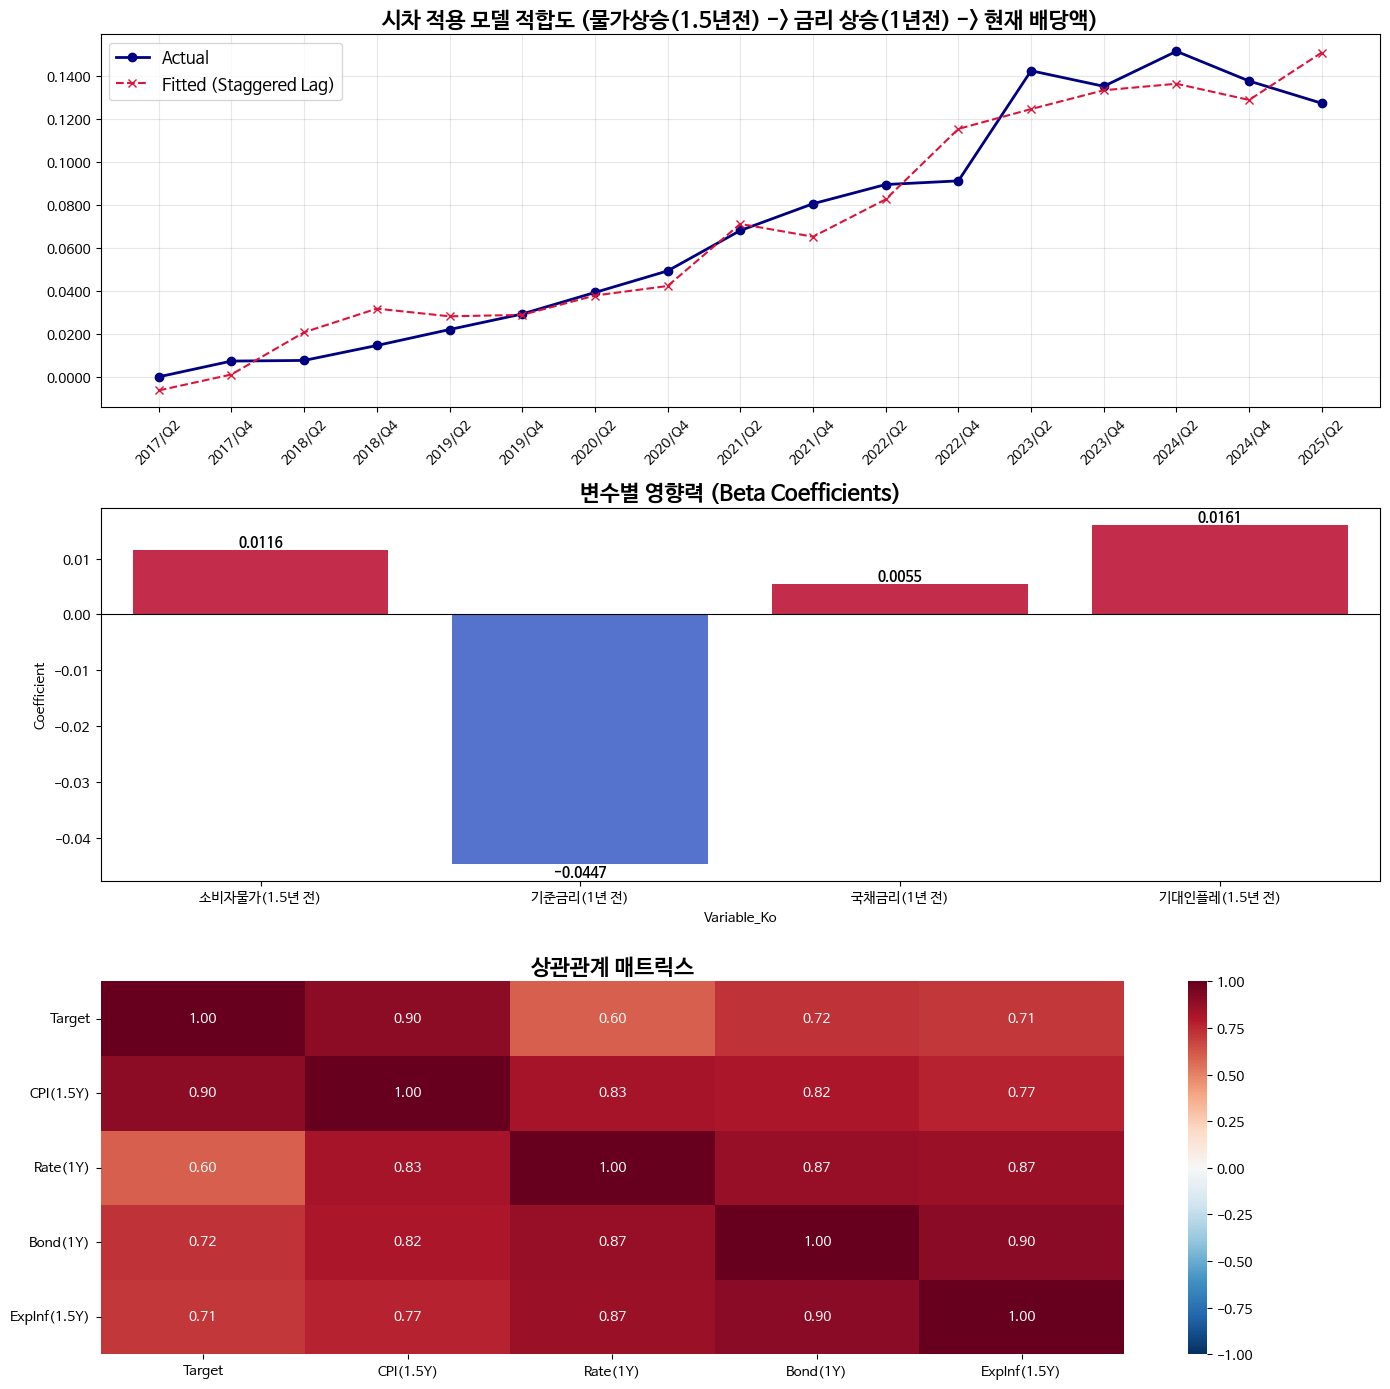

        lval  op       rval  Estimate  p-value
0  Past_Rate   ~   Past_CPI    0.8295   0.0000
1     Target   ~   Past_CPI    1.2827   0.0000
2     Target   ~  Past_Rate   -0.4659   0.0028
3  Past_Rate  ~~  Past_Rate    0.2936   0.0036
4     Target  ~~     Target    0.1211   0.0036


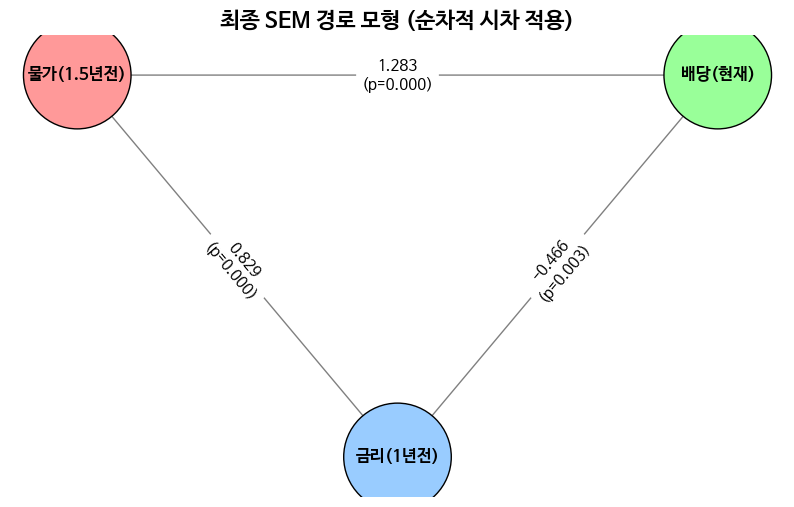

1. 직접 효과: 1.2827
2. 간접 효과: -0.3864
3. 총 효과: 0.8963


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import sys
import subprocess
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4f}'.format

def install_and_import(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    except:
        pass

try:
    import semopy
except ImportError:
    install_and_import('semopy')
    import semopy

def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False
    else:
        pass

set_korean_font()

file_paths = {
    'base_rate': 'base_rate.csv',
    'cpi': 'cpi.csv',
    'bond': 'bond.csv',
    'capital': 'capital.csv',
    'dividend': 'dividend2.csv'
}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]

    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    return df_val

df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')
df_bond = preprocess_macro(read_csv_safe(file_paths['bond']), 'Bond_Yield')

df_macro_semi = None
market_div = None

if all(v is not None for v in [df_base, df_cpi, df_bond]):
    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')
    df_macro = pd.merge(df_macro, df_bond, on='Date', how='inner')

    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)

    df_macro['CPI_Lag4'] = df_macro['CPI'].shift(4)
    df_macro['Exp_Inflation'] = (df_macro['CPI'] - df_macro['CPI_Lag4']) / df_macro['CPI_Lag4'] * 100

    df_macro_semi = df_macro[df_macro['Quarter'].isin([2, 4])].copy()

    df_macro_semi['CPI_Lag_18M'] = df_macro_semi['CPI'].shift(3)
    df_macro_semi['Base_Rate_Lag_1Y'] = df_macro_semi['Base_Rate'].shift(2)
    df_macro_semi['Bond_Yield_Lag_1Y'] = df_macro_semi['Bond_Yield'].shift(2)
    df_macro_semi['Exp_Inflation_Lag_18M'] = df_macro_semi['Exp_Inflation'].shift(3)

    df_macro_semi['Semi_Year_Match'] = df_macro_semi['Quarter'].apply(lambda x: 1 if x==2 else 2)

df_div = read_csv_safe(file_paths['dividend'])
if df_div is not None:
    df_div.columns = df_div.columns.str.strip()
    if 'dividend' in df_div.columns:
        df_div['dividend'] = df_div['dividend'].astype(str).str.replace(',', '')
        df_div['dividend'] = pd.to_numeric(df_div['dividend'], errors='coerce')
        df_div['semi-year'] = df_div['month'].apply(lambda x: 1 if x <= 6 else 2)
        market_div = df_div.groupby(['year', 'semi-year'])['dividend'].sum().reset_index()

def run_staggered_model():
    df_capital = read_csv_safe(file_paths['capital'])
    if df_capital is None or market_div is None or df_macro_semi is None:
        return

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']],
                      left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year'], how='inner')

    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']

    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year_Match'], how='inner')

    df_reg = df_final.dropna().reset_index(drop=True)

    if len(df_reg) < 5:
        return

    X_cols = ['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Bond_Yield_Lag_1Y', 'Exp_Inflation_Lag_18M']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    print(model.summary())

    coef_df = pd.DataFrame({'Variable': X.columns[1:], 'Coefficient': model.params[1:]})
    name_mapping = {
        'CPI_Lag_18M': '소비자물가(1.5년 전)',
        'Base_Rate_Lag_1Y': '기준금리(1년 전)',
        'Bond_Yield_Lag_1Y': '국채금리(1년 전)',
        'Exp_Inflation_Lag_18M': '기대인플레(1.5년 전)'
    }
    coef_df['Variable_Ko'] = coef_df['Variable'].map(name_mapping)

    plt.figure(figsize=(14, 14))

    plt.subplot(3, 1, 1)
    plt.plot(df_reg['Date'], y, label='Actual', marker='o', linewidth=2, color='navy')
    plt.plot(df_reg['Date'], model.predict(X), label='Fitted (Staggered Lag)', linestyle='--', marker='x', color='crimson')
    plt.title('시차 적용 모델 적합도 (물가상승(1.5년전) -> 금리 상승(1년전) -> 현재 배당액)', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    plt.subplot(3, 1, 2)
    colors = ['crimson' if x > 0 else 'royalblue' for x in coef_df['Coefficient']]
    bar_plot = sns.barplot(x='Variable_Ko', y='Coefficient', data=coef_df, palette=colors)
    plt.title('변수별 영향력 (Beta Coefficients)', fontsize=16, fontweight='bold')
    plt.axhline(0, color='black', linewidth=0.8)
    for p in bar_plot.patches:
        val = p.get_height()
        plt.text(p.get_x() + p.get_width()/2, val, f'{val:.4f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')

    plt.subplot(3, 1, 3)
    corr_cols = ['Div_to_Capital'] + X_cols
    corr_data = df_reg[corr_cols].copy()
    corr_data.columns = ['Target', 'CPI(1.5Y)', 'Rate(1Y)', 'Bond(1Y)', 'ExpInf(1.5Y)']
    sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
    plt.title('상관관계 매트릭스', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

    df_sem = df_reg[['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Div_to_Capital']].copy()
    df_sem.columns = ['Past_CPI', 'Past_Rate', 'Target']
    df_sem = (df_sem - df_sem.mean()) / df_sem.std()

    desc = """
    Past_Rate ~ Past_CPI
    Target ~ Past_CPI + Past_Rate
    """
    try:
        model_sem = semopy.Model(desc)
        result_sem = model_sem.fit(df_sem)
        estimates = model_sem.inspect()

        print(estimates[['lval', 'op', 'rval', 'Estimate', 'p-value']].to_string(float_format=lambda x: "{:.4f}".format(x)))

        plt.figure(figsize=(10, 6))
        G = nx.DiGraph()
        pos = {'Past_CPI': (0, 1), 'Past_Rate': (1, 0), 'Target': (2, 1)}
        labels = {'Past_CPI': '물가(1.5년전)', 'Past_Rate': '금리(1년전)', 'Target': '배당(현재)'}

        edges = []
        edge_labels = {}

        def get_est_p(l, r):
            row = estimates[(estimates['lval']==l) & (estimates['rval']==r)]
            if len(row) > 0:
                return row['Estimate'].values[0], row['p-value'].values[0]
            return 0, 1

        est1, p1 = get_est_p('Past_Rate', 'Past_CPI')
        edges.append(('Past_CPI', 'Past_Rate'))
        edge_labels[('Past_CPI', 'Past_Rate')] = f"{est1:.3f}\n(p={p1:.3f})"

        est2, p2 = get_est_p('Target', 'Past_Rate')
        edges.append(('Past_Rate', 'Target'))
        edge_labels[('Past_Rate', 'Target')] = f"{est2:.3f}\n(p={p2:.3f})"

        est3, p3 = get_est_p('Target', 'Past_CPI')
        edges.append(('Past_CPI', 'Target'))
        edge_labels[('Past_CPI', 'Target')] = f"{est3:.3f}\n(p={p3:.3f})"

        G.add_edges_from(edges)
        nx.draw_networkx_nodes(G, pos, node_size=6000, node_color=['#FF9999', '#99CCFF', '#99FF99'], edgecolors='black')
        nx.draw_networkx_labels(G, pos, labels=labels, font_family='NanumBarunGothic', font_size=12, font_weight='bold')
        nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle='-|>', arrowsize=25, edge_color='gray')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_family='NanumBarunGothic', font_size=11)
        plt.title("최종 SEM 경로 모형 (순차적 시차 적용)", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.show()

        dir_eff = est3
        ind_eff = est1 * est2
        tot_eff = dir_eff + ind_eff

        print(f"1. 직접 효과: {dir_eff:.4f}")
        print(f"2. 간접 효과: {ind_eff:.4f}")
        print(f"3. 총 효과: {tot_eff:.4f}")

    except Exception as e:
        print(e)

run_staggered_model()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

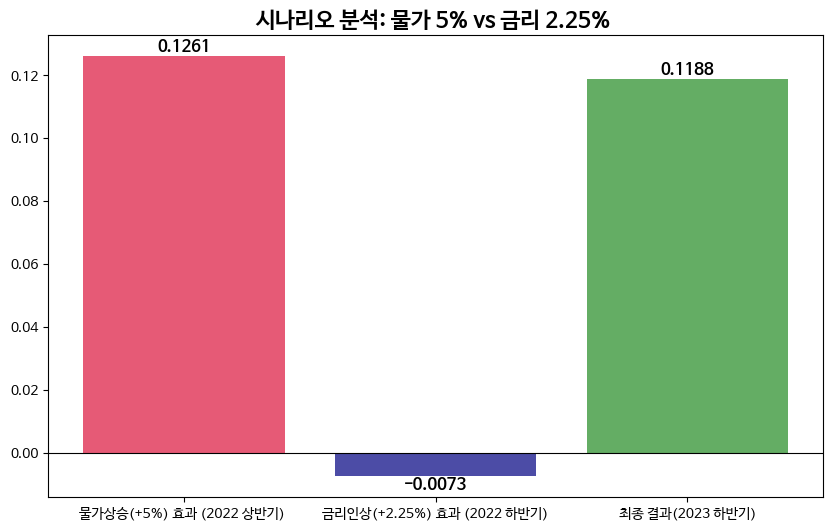

In [ ]:
# 1. 기본 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import sys
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4f}'.format

def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# 2. 데이터 로딩 및 전처리
file_paths = {
    'base_rate': 'base_rate.csv',
    'cpi': 'cpi.csv',
    'bond': 'bond.csv',
    'capital': 'capital.csv',
    'dividend': 'dividend2.csv'
}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]
    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    return df_val

# 3. 메인 분석 실행
def run_final_scenario_analysis():
    print(f"\n{'='*60}")
    print(f" [최종 검증] 2022년 하반기 시나리오 적용")
    print(f" 변수: 물가상승률(YoY %), 기준금리(%)")
    print(f"{'='*60}")

    # 데이터 로드
    df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
    df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')
    df_bond = preprocess_macro(read_csv_safe(file_paths['bond']), 'Bond_Yield')
    df_div = read_csv_safe(file_paths['dividend'])
    df_capital = read_csv_safe(file_paths['capital'])

    if not all(v is not None for v in [df_base, df_cpi, df_bond, df_div, df_capital]):
        print("파일 누락")
        return

    # 매크로 병합 및 물가상승률 계산
    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')
    df_macro = pd.merge(df_macro, df_bond, on='Date', how='inner')
    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)

    # [핵심] 전년 동기 대비 물가상승률 계산
    df_macro['Inflation_Rate_YoY'] = df_macro['CPI'].pct_change(4) * 100

    # 반기 데이터 필터링 및 시차 적용
    df_macro_semi = df_macro[df_macro['Quarter'].isin([2, 4])].copy()
    # 물가상승률: 1.5년 전 (Lag 3), 금리: 1년 전 (Lag 2)
    df_macro_semi['Inflation_Lag_18M'] = df_macro_semi['Inflation_Rate_YoY'].shift(3)
    df_macro_semi['Rate_Lag_1Y'] = df_macro_semi['Base_Rate'].shift(2)
    df_macro_semi['Semi_Year_Match'] = df_macro_semi['Quarter'].apply(lambda x: 1 if x==2 else 2)

    # 배당 및 자본금 처리
    df_div.columns = df_div.columns.str.strip()
    df_div['dividend'] = pd.to_numeric(df_div['dividend'].astype(str).str.replace(',', ''), errors='coerce')
    df_div['semi-year'] = df_div['month'].apply(lambda x: 1 if x <= 6 else 2)
    market_div = df_div.groupby(['year', 'semi-year'])['dividend'].sum().reset_index()
    market_div.rename(columns={'year': 'Year', 'semi-year': 'Semi_Year'}, inplace=True)

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']], on=['Year', 'Semi_Year'], how='inner')
    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']

    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['Year', 'Semi_Year'], right_on=['Year', 'Semi_Year_Match'], how='inner')
    df_reg = df_final.dropna().reset_index(drop=True)

    # 회귀분석 실행
    X_cols = ['Inflation_Lag_18M', 'Rate_Lag_1Y']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    print("\n[회귀분석 결과]")
    print(model.summary())

    # 시나리오 시뮬레이션
    beta_infl = model.params['Inflation_Lag_18M']
    beta_rate = model.params['Rate_Lag_1Y']

    delta_infl = 5.0   # 물가상승률 +5%p
    delta_rate = 2.25  # 금리 +2.25%p

    effect_infl = beta_infl * delta_infl
    effect_rate = beta_rate * delta_rate
    net_effect = effect_infl + effect_rate

    print(f"\n[시나리오: 물가 +5%p vs 금리 +2.25%p]")
    print(f"1. 물가상승 효과: 배당률 {effect_infl:.4f} 상승 (▲)")
    print(f"2. 금리인상 타격: 배당률 {effect_rate:.4f} 하락 (▼)")
    print("-" * 40)
    print(f"3. 최종 결과 (Net): {net_effect:.4f}")

    if net_effect > 0:
        print(f"\n>>> [최종 결론] 리츠 승리! (배당률 {net_effect*100:.2f}%p 상승)")
    else:
        print("\n>>> [최종 결론] 리츠 패배")

    # 시각화
    plt.figure(figsize=(10, 6))
    effects = [effect_infl, effect_rate, net_effect]
    labels = ['물가상승(+5%) 효과 (2022 상반기) ', '금리인상(+2.25%) 효과 (2022 하반기)', '최종 결과(2023 하반기)']
    colors = ['crimson', 'navy', 'forestgreen']

    bar_plot = plt.bar(labels, effects, color=colors, alpha=0.7)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title('시나리오 분석: 물가 5% vs 금리 2.25% ', fontsize=16, fontweight='bold')

    for rect in bar_plot:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2.0, height, f'{height:.4f}',
                 ha='center', va='bottom' if height>0 else 'top', fontweight='bold', fontsize=12)
    plt.show()

run_final_scenario_analysis()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

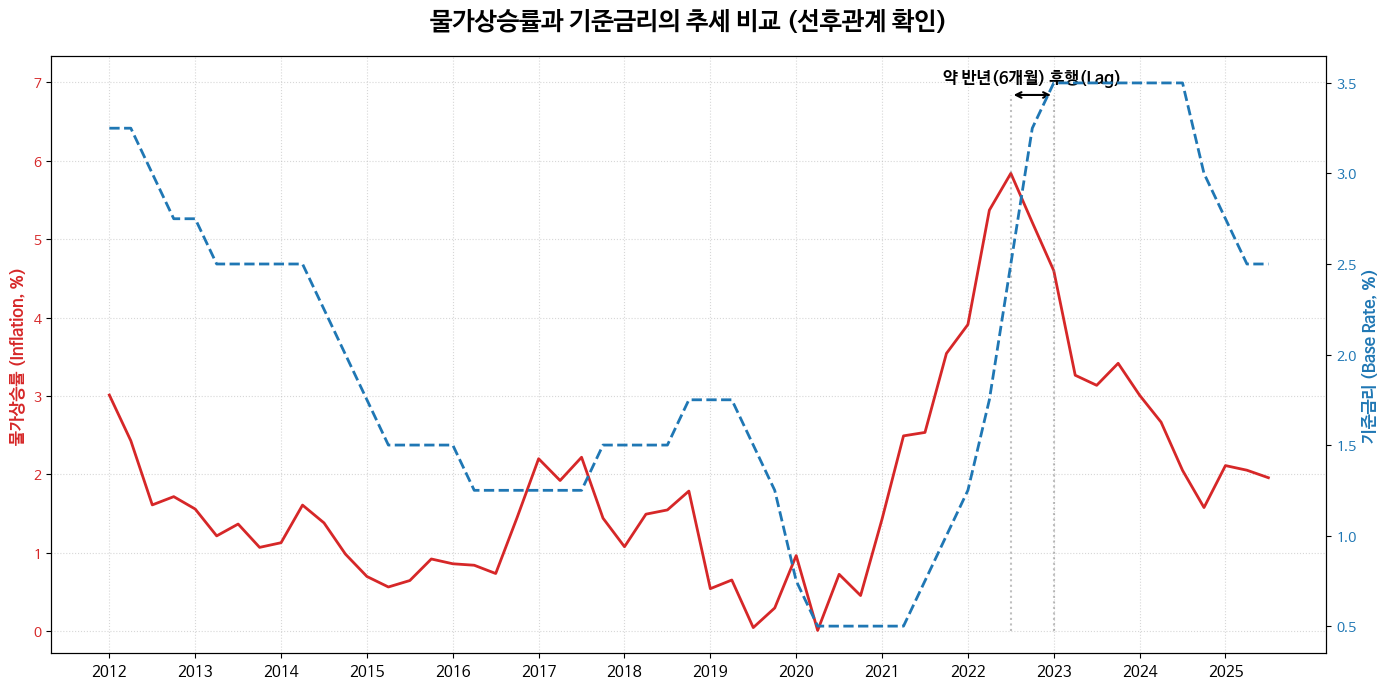

In [ ]:
# 1. 이 셀을 실행합니다.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 실행이 완료되면 상단 메뉴에서 [런타임] -> [세션 다시 시작]을 누르세요.
# 3. 그 다음 아래 '2단계' 코드를 실행하세요.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import warnings

# ==============================================================================
# 1. 폰트 설정 (나눔바른고딕 강제 적용)
# ==============================================================================
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
warnings.filterwarnings("ignore")

# ==============================================================================
# 2. 데이터 불러오기 (기존 방식 유지)
# ==============================================================================
file_paths = {'base_rate': 'base_rate.csv', 'cpi': 'cpi.csv'}

def preprocess_macro_quarterly(df, col_name):
    if df is None: return None
    # 데이터 구조에 따라 유연하게 컬럼 찾기
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]

    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)

    # 정렬을 위한 연/분기 추출
    df_val['Year'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_val['Quarter'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_val = df_val.sort_values(['Year', 'Quarter']).reset_index(drop=True)
    return df_val

# CSV 파일 읽기
try:
    df_base = preprocess_macro_quarterly(pd.read_csv('base_rate.csv', encoding='utf-8'), 'Base_Rate')
    df_cpi = preprocess_macro_quarterly(pd.read_csv('cpi.csv', encoding='utf-8'), 'CPI')
except:
    # 인코딩 에러 시 cp949 시도
    df_base = preprocess_macro_quarterly(pd.read_csv('base_rate.csv', encoding='cp949'), 'Base_Rate')
    df_cpi = preprocess_macro_quarterly(pd.read_csv('cpi.csv', encoding='cp949'), 'CPI')

# 데이터 병합
if df_base is not None and df_cpi is not None:
    df = pd.merge(df_base, df_cpi, on=['Date', 'Year', 'Quarter'], how='inner')
    df['Inflation'] = df['CPI'].pct_change(4) * 100
    df_clean = df.dropna().reset_index(drop=True)

    # ==============================================================================
    # 3. 그래프 그리기 (요청하신 스타일 완벽 반영)
    # ==============================================================================
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # (1) 물가상승률 (빨강)
    color_1 = '#d62728'
    ax1.set_ylabel('물가상승률 (Inflation, %)', color=color_1, fontweight='bold', fontsize=12)
    ax1.plot(df_clean.index, df_clean['Inflation'], color=color_1, linewidth=2, label='물가상승률')
    ax1.tick_params(axis='y', labelcolor=color_1)

    # (2) 기준금리 (파랑 점선)
    ax2 = ax1.twinx()
    color_2 = '#1f77b4'
    ax2.set_ylabel('기준금리 (Base Rate, %)', color=color_2, fontweight='bold', fontsize=12)
    ax2.plot(df_clean.index, df_clean['Base_Rate'], color=color_2, linestyle='--', linewidth=2, label='기준금리')
    ax2.tick_params(axis='y', labelcolor=color_2)

    # (3) [핵심] X축 깔끔하게 (년도만 표시)
    # 4개 간격(1년 단위)으로 눈금 설정
    tick_idxs = np.arange(0, len(df_clean), 4)
    tick_labels = [str(df_clean['Date'][i]).split('/')[0] for i in tick_idxs] # "2012"만 추출

    ax1.set_xticks(tick_idxs)
    ax1.set_xticklabels(tick_labels, rotation=0, fontsize=11)
    ax1.set_xlabel('')

    # (4) [핵심] 반년(6개월) 시차 화살표
    # 2022년 고점 찾기
    try:
        mask_2022 = df_clean['Date'].astype(str).str.contains('2022')
        if mask_2022.any():
            idx_inf_peak = df_clean.loc[mask_2022, 'Inflation'].idxmax()

            # 반년 뒤 (2분기 뒤)
            idx_rate_peak = idx_inf_peak + 2

            # 화살표 그릴 높이 (그래프보다 위쪽)
            y_limit = max(df_clean['Inflation'].max(), df_clean['Base_Rate'].max()) + 1.5
            ax1.set_ylim(top=y_limit)

            arrow_y = y_limit - 0.5

            # 화살표 그리기
            ax1.annotate('',
                         xy=(idx_inf_peak, arrow_y),
                         xytext=(idx_rate_peak, arrow_y),
                         arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))

            # 텍스트 표시
            ax1.text((idx_inf_peak + idx_rate_peak)/2, arrow_y + 0.1, "약 반년(6개월) 후행(Lag)",
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

            # 보조선 (선택)
            ax1.vlines([idx_inf_peak, idx_rate_peak], 0, arrow_y, color='gray', linestyle=':', alpha=0.5)

    except Exception as e:
        print("화살표 표시 실패:", e)

    # 제목 및 그리드
    plt.title('물가상승률과 기준금리의 추세 비교 (선후관계 확인)', fontsize=18, fontweight='bold', pad=20)
    ax1.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("CSV 파일이 없습니다. base_rate.csv, cpi.csv 파일을 업로드해주세요.")

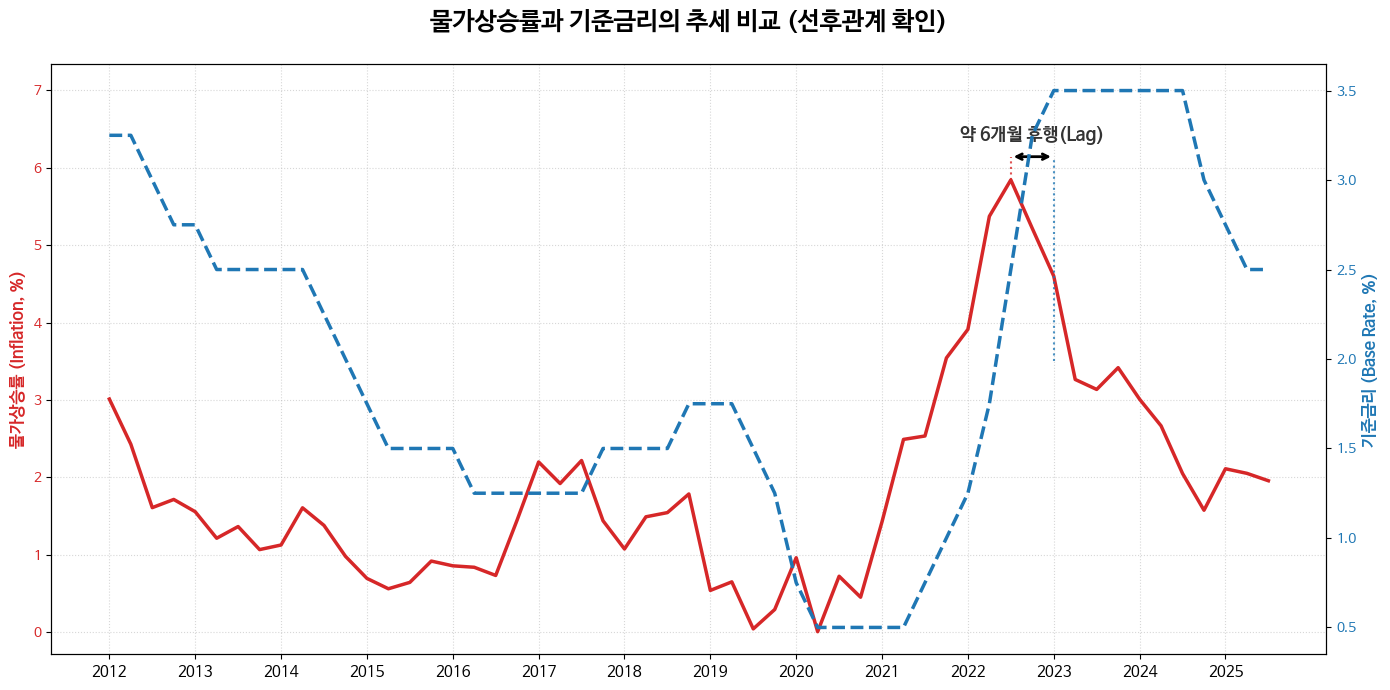

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import warnings
import sys
import matplotlib.font_manager as fm

# ==============================================================================
# 1. 폰트 설정 (Colab / 로컬 자동 대응)
# ==============================================================================
warnings.filterwarnings("ignore")

if 'google.colab' in sys.modules:
    # 폰트 설치가 안 되어 있을 경우를 대비해 매번 확인하지 않고 설정만 시도
    plt.rc('font', family='NanumBarunGothic')
else:
    if os.name == 'nt': plt.rc('font', family='Malgun Gothic')
    elif sys.platform == 'darwin': plt.rc('font', family='AppleGothic')
    else: plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 2. 데이터 불러오기 및 전처리
# ==============================================================================
def preprocess_macro_quarterly(df, col_name):
    if df is None: return None
    # 데이터 구조에 따라 유연하게 컬럼 찾기
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]

    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    df_val['Year'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_val['Quarter'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_val = df_val.sort_values(['Year', 'Quarter']).reset_index(drop=True)
    return df_val

try:
    df_base = preprocess_macro_quarterly(pd.read_csv('base_rate.csv', encoding='utf-8'), 'Base_Rate')
    df_cpi = preprocess_macro_quarterly(pd.read_csv('cpi.csv', encoding='utf-8'), 'CPI')
except:
    try:
        df_base = preprocess_macro_quarterly(pd.read_csv('base_rate.csv', encoding='cp949'), 'Base_Rate')
        df_cpi = preprocess_macro_quarterly(pd.read_csv('cpi.csv', encoding='cp949'), 'CPI')
    except:
        print("파일을 읽을 수 없습니다.")

if df_base is not None and df_cpi is not None:
    df = pd.merge(df_base, df_cpi, on=['Date', 'Year', 'Quarter'], how='inner')
    df['Inflation'] = df['CPI'].pct_change(4) * 100
    df_clean = df.dropna().reset_index(drop=True)

    # ==============================================================================
    # 3. 그래프 그리기 (위치 조정 완료)
    # ==============================================================================
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # (1) 물가상승률 (빨강 실선)
    color_1 = '#d62728'
    ax1.set_ylabel('물가상승률 (Inflation, %)', color=color_1, fontweight='bold', fontsize=12)
    ax1.plot(df_clean.index, df_clean['Inflation'], color=color_1, linewidth=2.5, label='물가상승률')
    ax1.tick_params(axis='y', labelcolor=color_1)

    # (2) 기준금리 (파랑 점선)
    ax2 = ax1.twinx()
    color_2 = '#1f77b4'
    ax2.set_ylabel('기준금리 (Base Rate, %)', color=color_2, fontweight='bold', fontsize=12)
    ax2.plot(df_clean.index, df_clean['Base_Rate'], color=color_2, linestyle='--', linewidth=2.5, label='기준금리')
    ax2.tick_params(axis='y', labelcolor=color_2)

    # (3) X축: 년도만 깔끔하게 (4분기 간격)
    tick_idxs = np.arange(0, len(df_clean), 4)
    tick_labels = [str(df_clean['Date'][i]).split('/')[0] for i in tick_idxs]
    ax1.set_xticks(tick_idxs)
    ax1.set_xticklabels(tick_labels, rotation=0, fontsize=11)
    ax1.set_xlabel('')

    # (4) [핵심 수정] "딱 반년 차이"가 가장 잘 보이는 곳(최고점)에 화살표 배치
    try:
        # 전체 기간 중 물가상승률이 가장 높은 지점(Peak) 찾기 (대략 2022년 7월경)
        idx_peak_inf = df_clean['Inflation'].idxmax()

        # 정확히 2분기(6개월) 뒤 지점
        idx_lagged = idx_peak_inf + 2

        # 화살표 높이 설정: 물가 최고점 바로 위쪽 (너무 높지 않게)
        peak_value = df_clean.loc[idx_peak_inf, 'Inflation']
        arrow_y = peak_value + 0.3 # 그래프 바로 위

        # Y축 범위 조정 (화살표가 잘리거나 너무 붕 뜨지 않게)
        ax1.set_ylim(top=peak_value + 1.5)

        # 화살표 그리기
        ax1.annotate('',
                     xy=(idx_peak_inf, arrow_y),
                     xytext=(idx_lagged, arrow_y),
                     arrowprops=dict(arrowstyle='<->', color='black', lw=2)) # 화살표 두께 강화

        # 텍스트: 화살표 중앙 바로 위
        ax1.text((idx_peak_inf + idx_lagged)/2, arrow_y + 0.15, "약 6개월 후행(Lag)",
                 ha='center', va='bottom', fontsize=13, fontweight='bold', color='#333333')

        # 시선 유도선 (Peak 지점과 Lag 지점을 아래로 연결)
        # 빨간색(물가) Peak에서 내려오는 선
        ax1.vlines(idx_peak_inf, df_clean.loc[idx_peak_inf, 'Inflation'], arrow_y,
                   color=color_1, linestyle=':', alpha=0.8, linewidth=1.5)
        # 파란색(금리) 대응 지점으로 내려오는 선
        ax1.vlines(idx_lagged, df_clean.loc[idx_lagged, 'Base_Rate'], arrow_y,
                   color=color_2, linestyle=':', alpha=0.8, linewidth=1.5)

    except Exception as e:
        print("화살표 표시 중 오류:", e)

    # 제목 및 그리드
    plt.title('물가상승률과 기준금리의 추세 비교 (선후관계 확인)', fontsize=18, fontweight='bold', pad=25)
    ax1.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("CSV 파일이 없습니다.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

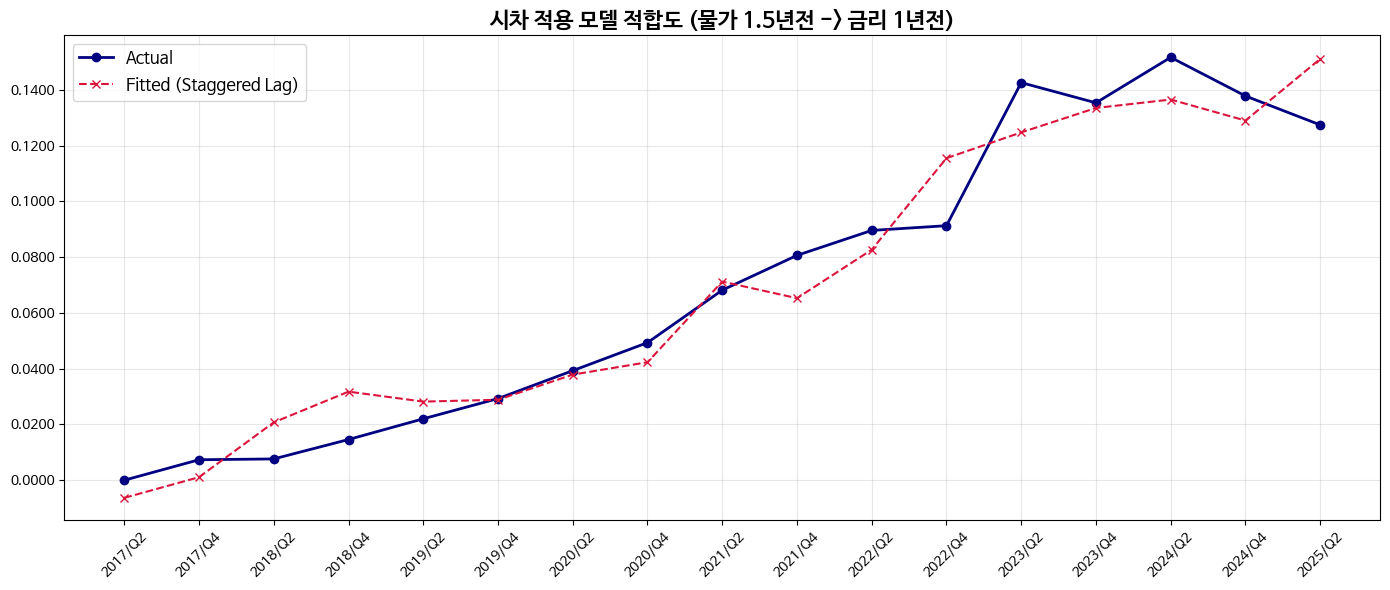

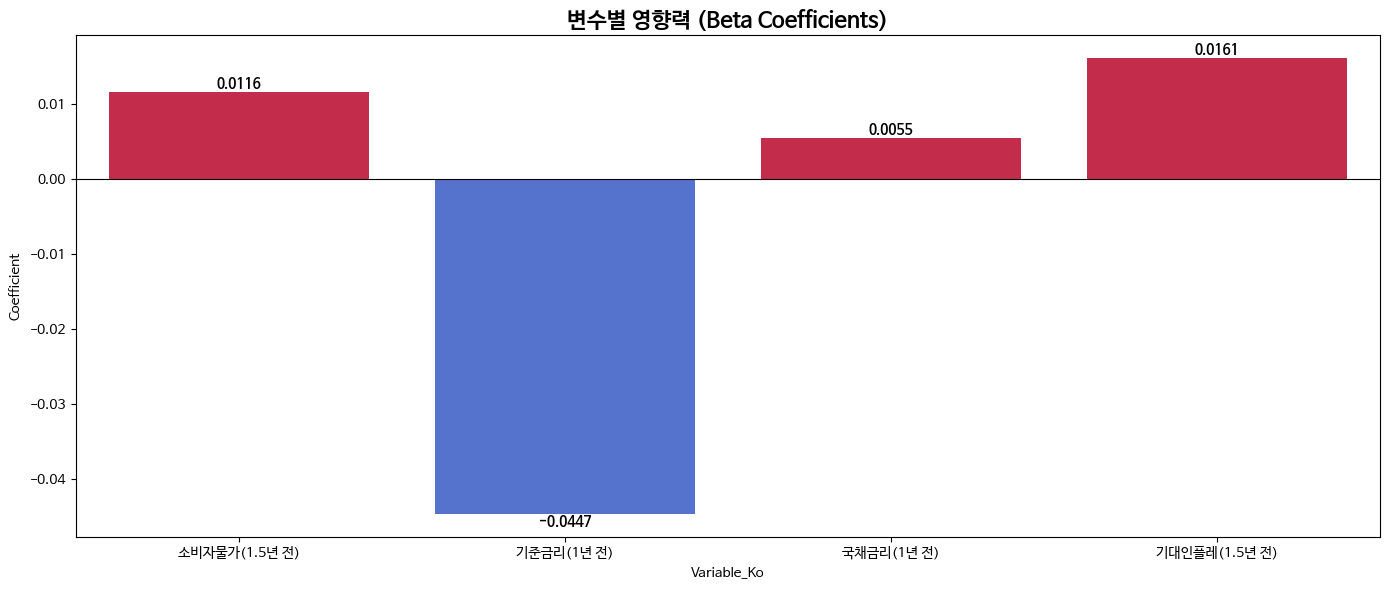

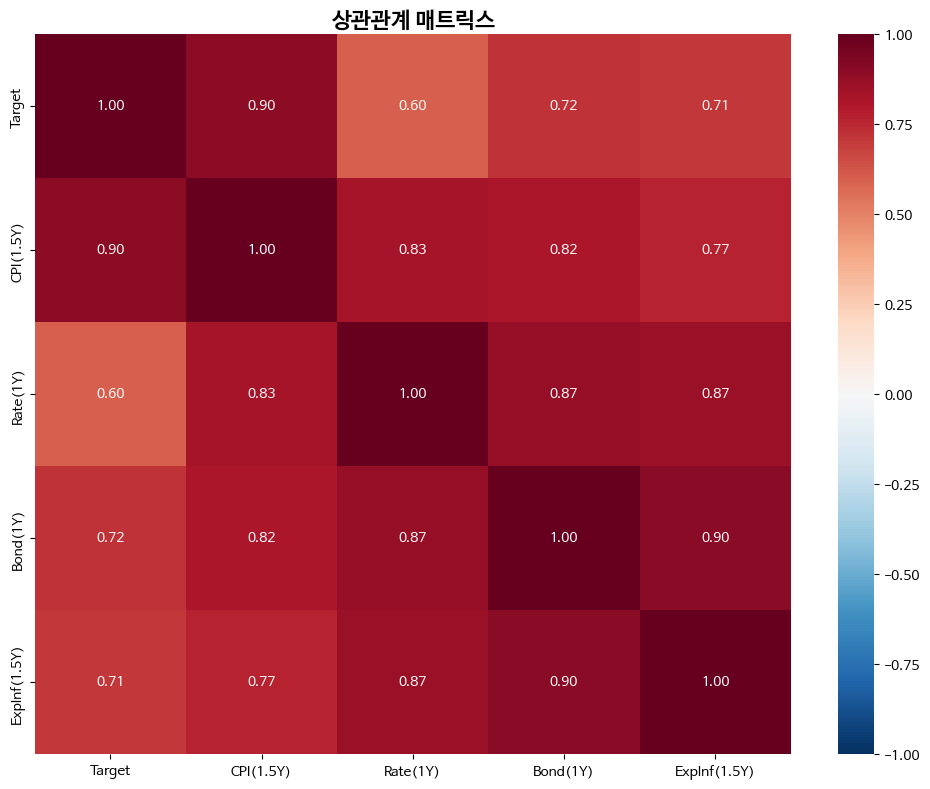

        lval  op       rval  Estimate  p-value
0  Past_Rate   ~   Past_CPI    0.8295   0.0000
1     Target   ~   Past_CPI    1.2827   0.0000
2     Target   ~  Past_Rate   -0.4659   0.0028
3  Past_Rate  ~~  Past_Rate    0.2936   0.0036
4     Target  ~~     Target    0.1211   0.0036


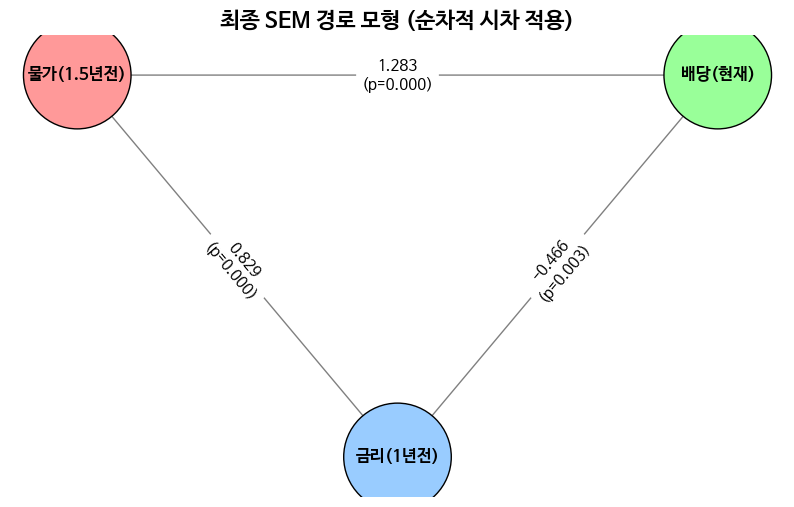

1. 직접 효과: 1.2827
2. 간접 효과: -0.3864
3. 총 효과: 0.8963


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import sys
import subprocess
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4f}'.format

# 1. 라이브러리 설치 및 폰트 설정 (기존 유지)
def install_and_import(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    except:
        pass

try:
    import semopy
except ImportError:
    install_and_import('semopy')
    import semopy

def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False
    else:
        pass

set_korean_font()

# 2. 데이터 로딩 및 전처리 (기존 유지)
file_paths = {
    'base_rate': 'base_rate.csv',
    'cpi': 'cpi.csv',
    'bond': 'bond.csv',
    'capital': 'capital.csv',
    'dividend': 'dividend2.csv'
}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]

    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    return df_val

df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')
df_bond = preprocess_macro(read_csv_safe(file_paths['bond']), 'Bond_Yield')

df_macro_semi = None
market_div = None

if all(v is not None for v in [df_base, df_cpi, df_bond]):
    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')
    df_macro = pd.merge(df_macro, df_bond, on='Date', how='inner')

    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)

    df_macro['CPI_Lag4'] = df_macro['CPI'].shift(4)
    df_macro['Exp_Inflation'] = (df_macro['CPI'] - df_macro['CPI_Lag4']) / df_macro['CPI_Lag4'] * 100

    df_macro_semi = df_macro[df_macro['Quarter'].isin([2, 4])].copy()

    df_macro_semi['CPI_Lag_18M'] = df_macro_semi['CPI'].shift(3)
    df_macro_semi['Base_Rate_Lag_1Y'] = df_macro_semi['Base_Rate'].shift(2)
    df_macro_semi['Bond_Yield_Lag_1Y'] = df_macro_semi['Bond_Yield'].shift(2)
    df_macro_semi['Exp_Inflation_Lag_18M'] = df_macro_semi['Exp_Inflation'].shift(3)

    df_macro_semi['Semi_Year_Match'] = df_macro_semi['Quarter'].apply(lambda x: 1 if x==2 else 2)

df_div = read_csv_safe(file_paths['dividend'])
if df_div is not None:
    df_div.columns = df_div.columns.str.strip()
    if 'dividend' in df_div.columns:
        df_div['dividend'] = df_div['dividend'].astype(str).str.replace(',', '')
        df_div['dividend'] = pd.to_numeric(df_div['dividend'], errors='coerce')
        df_div['semi-year'] = df_div['month'].apply(lambda x: 1 if x <= 6 else 2)
        market_div = df_div.groupby(['year', 'semi-year'])['dividend'].sum().reset_index()

# 3. 모델 실행 및 시각화 (그래프 분리 수정됨)
def run_staggered_model():
    df_capital = read_csv_safe(file_paths['capital'])
    if df_capital is None or market_div is None or df_macro_semi is None:
        return

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']],
                      left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year'], how='inner')

    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']

    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year_Match'], how='inner')

    df_reg = df_final.dropna().reset_index(drop=True)

    if len(df_reg) < 5:
        return

    X_cols = ['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Bond_Yield_Lag_1Y', 'Exp_Inflation_Lag_18M']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    print(model.summary())

    coef_df = pd.DataFrame({'Variable': X.columns[1:], 'Coefficient': model.params[1:]})
    name_mapping = {
        'CPI_Lag_18M': '소비자물가(1.5년 전)',
        'Base_Rate_Lag_1Y': '기준금리(1년 전)',
        'Bond_Yield_Lag_1Y': '국채금리(1년 전)',
        'Exp_Inflation_Lag_18M': '기대인플레(1.5년 전)'
    }
    coef_df['Variable_Ko'] = coef_df['Variable'].map(name_mapping)

    # ==========================================================================
    # [수정됨] 그래프 1: 시차 적용 모델 적합도
    # ==========================================================================
    plt.figure(figsize=(14, 6)) # 개별 사이즈 설정
    plt.plot(df_reg['Date'], y, label='Actual', marker='o', linewidth=2, color='navy')
    plt.plot(df_reg['Date'], model.predict(X), label='Fitted (Staggered Lag)', linestyle='--', marker='x', color='crimson')
    plt.title('시차 적용 모델 적합도 (물가 1.5년전 -> 금리 1년전)', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
    plt.tight_layout()
    plt.show()

    # ==========================================================================
    # [수정됨] 그래프 2: 변수별 영향력 (Beta Coefficients)
    # ==========================================================================
    plt.figure(figsize=(14, 6)) # 개별 사이즈 설정
    colors = ['crimson' if x > 0 else 'royalblue' for x in coef_df['Coefficient']]
    bar_plot = sns.barplot(x='Variable_Ko', y='Coefficient', data=coef_df, palette=colors)
    plt.title('변수별 영향력 (Beta Coefficients)', fontsize=16, fontweight='bold')
    plt.axhline(0, color='black', linewidth=0.8)
    for p in bar_plot.patches:
        val = p.get_height()
        plt.text(p.get_x() + p.get_width()/2, val, f'{val:.4f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================================================
    # [수정됨] 그래프 3: 상관관계 매트릭스
    # ==========================================================================
    plt.figure(figsize=(10, 8)) # 개별 사이즈 설정
    corr_cols = ['Div_to_Capital'] + X_cols
    corr_data = df_reg[corr_cols].copy()
    corr_data.columns = ['Target', 'CPI(1.5Y)', 'Rate(1Y)', 'Bond(1Y)', 'ExpInf(1.5Y)']
    sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
    plt.title('상관관계 매트릭스', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================================================
    # [유지] SEM 분석 및 시각화 (원래 따로 그려졌으나 명확히 분리)
    # ==========================================================================
    df_sem = df_reg[['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Div_to_Capital']].copy()
    df_sem.columns = ['Past_CPI', 'Past_Rate', 'Target']
    df_sem = (df_sem - df_sem.mean()) / df_sem.std()

    desc = """
    Past_Rate ~ Past_CPI
    Target ~ Past_CPI + Past_Rate
    """
    try:
        model_sem = semopy.Model(desc)
        result_sem = model_sem.fit(df_sem)
        estimates = model_sem.inspect()

        print(estimates[['lval', 'op', 'rval', 'Estimate', 'p-value']].to_string(float_format=lambda x: "{:.4f}".format(x)))

        # 그래프 4: SEM 경로 모형
        plt.figure(figsize=(10, 6))
        G = nx.DiGraph()
        pos = {'Past_CPI': (0, 1), 'Past_Rate': (1, 0), 'Target': (2, 1)}
        labels = {'Past_CPI': '물가(1.5년전)', 'Past_Rate': '금리(1년전)', 'Target': '배당(현재)'}

        edges = []
        edge_labels = {}

        def get_est_p(l, r):
            row = estimates[(estimates['lval']==l) & (estimates['rval']==r)]
            if len(row) > 0:
                return row['Estimate'].values[0], row['p-value'].values[0]
            return 0, 1

        est1, p1 = get_est_p('Past_Rate', 'Past_CPI')
        edges.append(('Past_CPI', 'Past_Rate'))
        edge_labels[('Past_CPI', 'Past_Rate')] = f"{est1:.3f}\n(p={p1:.3f})"

        est2, p2 = get_est_p('Target', 'Past_Rate')
        edges.append(('Past_Rate', 'Target'))
        edge_labels[('Past_Rate', 'Target')] = f"{est2:.3f}\n(p={p2:.3f})"

        est3, p3 = get_est_p('Target', 'Past_CPI')
        edges.append(('Past_CPI', 'Target'))
        edge_labels[('Past_CPI', 'Target')] = f"{est3:.3f}\n(p={p3:.3f})"

        G.add_edges_from(edges)
        nx.draw_networkx_nodes(G, pos, node_size=6000, node_color=['#FF9999', '#99CCFF', '#99FF99'], edgecolors='black')
        nx.draw_networkx_labels(G, pos, labels=labels, font_family='NanumBarunGothic', font_size=12, font_weight='bold')
        nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle='-|>', arrowsize=25, edge_color='gray')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_family='NanumBarunGothic', font_size=11)
        plt.title("최종 SEM 경로 모형 (순차적 시차 적용)", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.show()

        dir_eff = est3
        ind_eff = est1 * est2
        tot_eff = dir_eff + ind_eff

        print(f"1. 직접 효과: {dir_eff:.4f}")
        print(f"2. 간접 효과: {ind_eff:.4f}")
        print(f"3. 총 효과: {tot_eff:.4f}")

    except Exception as e:
        print(e)

run_staggered_model()

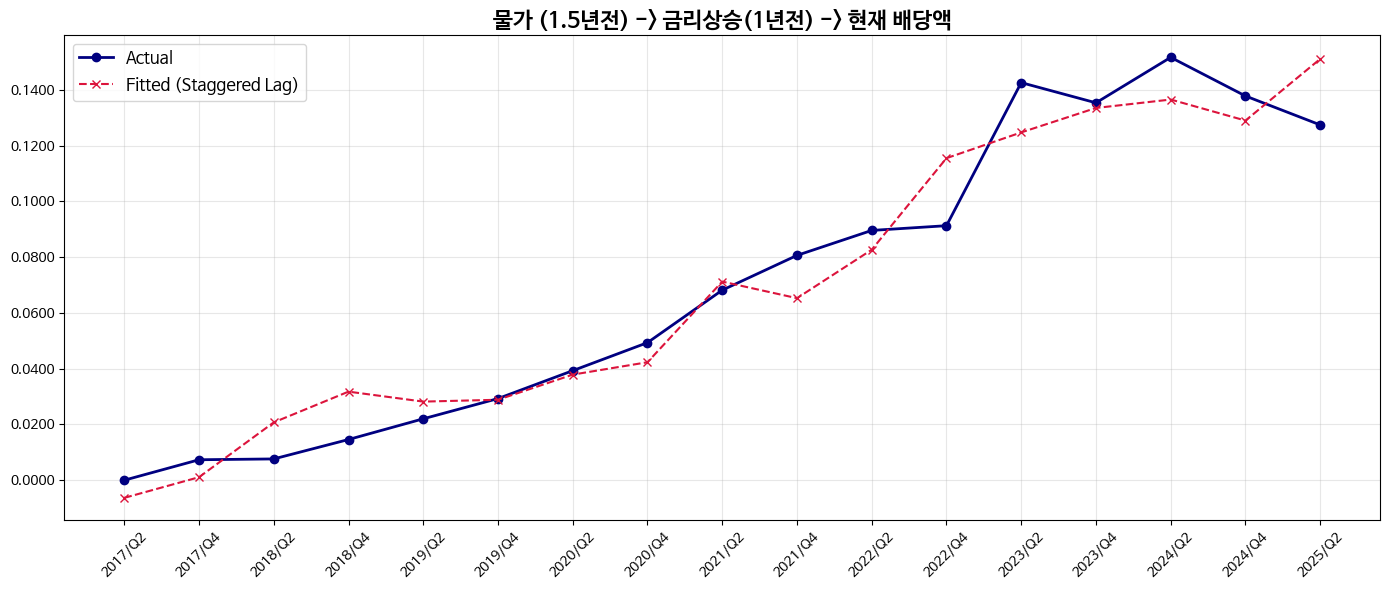

In [ ]:
# ==============================================================================
# [수정됨] 딱 이 그래프 하나만 그리는 코드 (제목 수정 완료)
# ==============================================================================
def run_staggered_model_only_fit():
    # 1. 데이터 준비 (기존 로직 동일)
    df_capital = read_csv_safe(file_paths['capital'])
    if df_capital is None or market_div is None or df_macro_semi is None:
        return

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']],
                      left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year'], how='inner')

    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']

    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year_Match'], how='inner')
    df_reg = df_final.dropna().reset_index(drop=True)

    if len(df_reg) < 5: return

    # 2. 회귀분석 수행
    X_cols = ['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Bond_Yield_Lag_1Y', 'Exp_Inflation_Lag_18M']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    # ==========================================================================
    # 3. [요청하신 부분] 그래프 그리기 (제목 수정됨)
    # ==========================================================================
    plt.figure(figsize=(14, 6))

    # 실제값
    plt.plot(df_reg['Date'], y, label='Actual', marker='o', linewidth=2, color='navy')

    # 예측값
    plt.plot(df_reg['Date'], model.predict(X), label='Fitted (Staggered Lag)', linestyle='--', marker='x', color='crimson')

    # [수정된 타이틀 적용]
    plt.title('물가 (1.5년전) -> 금리상승(1년전) -> 현재 배당액', fontsize=16, fontweight='bold')

    plt.xticks(rotation=45)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    plt.tight_layout()
    plt.show()

# 실행
run_staggered_model_only_fit()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

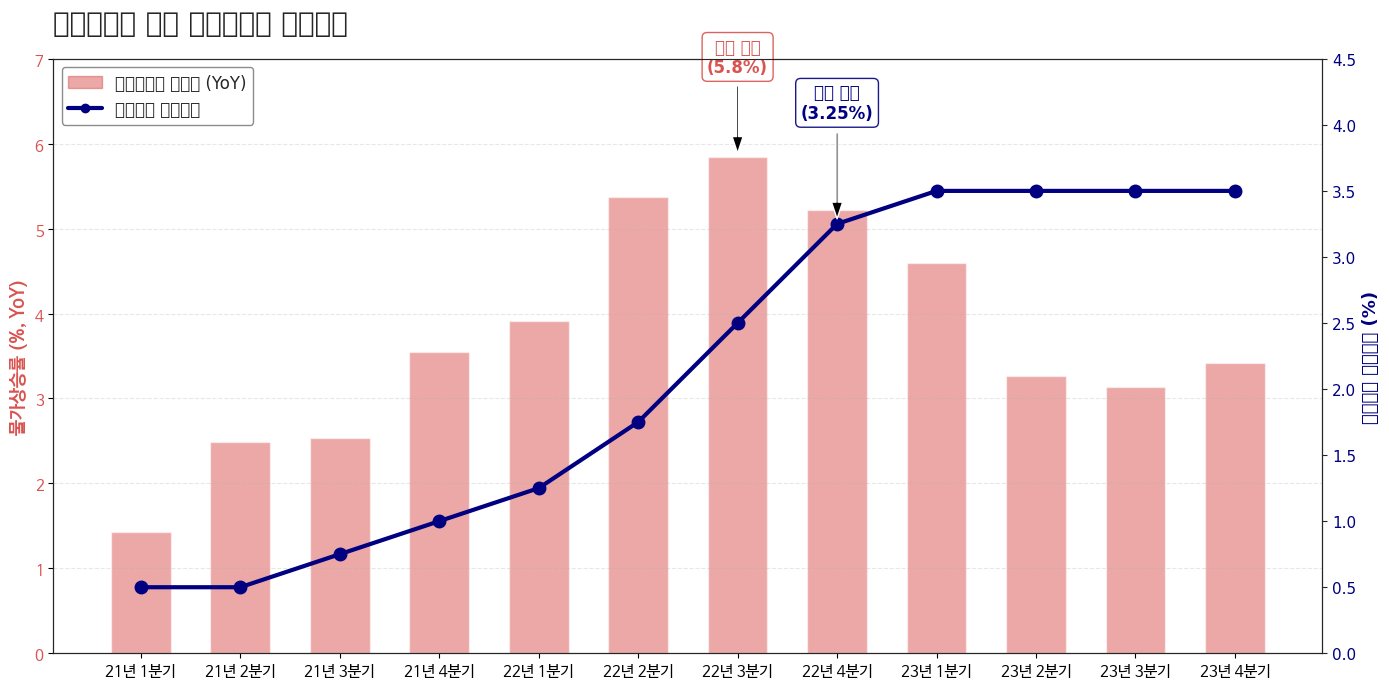

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import sys
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import seaborn as sns

warnings.filterwarnings("ignore")

# 1. 한글 폰트 설정
def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# 2. 데이터 준비
file_paths = {'base_rate': 'base_rate.csv', 'cpi': 'cpi.csv'}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]
    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    return df_val

def draw_final_chart():
    # 데이터 로드 및 전처리
    df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
    df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')

    if df_base is None or df_cpi is None:
        print("데이터 파일이 없습니다.")
        return

    # 병합
    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')

    # 날짜 정렬 및 필터링용 컬럼 생성
    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)

    # 물가상승률(YoY) 계산
    df_macro['CPI_YoY'] = df_macro['CPI'].pct_change(4) * 100

    # 2021~2023년 데이터만 추출
    df_plot = df_macro[(df_macro['Year'] >= 2021) & (df_macro['Year'] <= 2023)].copy()

    # X축 라벨 한글화 (2021/Q1 -> 21년 1분기)
    df_plot['Date_Ko'] = df_plot['Date'].apply(lambda x: f"{x.split('/')[0][2:]}년 {x.split('/')[1].replace('Q', '')}분기")

    # === 그래프 그리기 시작 ===
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # 스타일 설정
    plt.rcParams['font.family'] = 'NanumBarunGothic'
    sns.set_style("white") # 배경 흰색

    # 1. 물가상승률 (Bar Chart)
    bars = ax1.bar(df_plot['Date_Ko'], df_plot['CPI_YoY'], color='#D9534F', alpha=0.5, width=0.6, zorder=1)
    ax1.set_ylabel('물가상승률 (%, YoY)', color='#D9534F', fontsize=13, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#D9534F', labelsize=11)
    ax1.tick_params(axis='x', labelsize=11, rotation=0) # X축 글자 크기 및 회전
    ax1.set_ylim(0, 7) # Y축 여유 공간 확보
    ax1.grid(axis='y', linestyle='--', alpha=0.3) # 가로 보조선만

    # 2. 기준금리 (Line Chart)
    ax2 = ax1.twinx()
    ax2.plot(df_plot['Date_Ko'], df_plot['Base_Rate'], color='#000080', marker='o', markersize=9, linewidth=3, zorder=2)
    ax2.set_ylabel('한국은행 기준금리 (%)', color='#000080', fontsize=13, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#000080', labelsize=11)
    ax2.set_ylim(0, 4.5) # Y축 여유 공간 확보

    # 3. 제목 (왼쪽 정렬, 굵게)
    plt.title('물가상승에 따른 한국은행의 금리조정', fontsize=20, fontweight='bold', loc='left', pad=20)

    # 4. 주석 (Annotations) - 화살표와 설명

    # (1) 물가 정점 (22년 2분기 ~ 3분기 최고점)
    # 데이터상 최고점 찾기
    peak_cpi = df_plot['CPI_YoY'].max()
    peak_idx = df_plot[df_plot['CPI_YoY'] == peak_cpi].index[0]
    x_loc_peak = list(df_plot.index).index(peak_idx) # X축 좌표 인덱스

    ax1.annotate(f'물가 정점\n({peak_cpi:.1f}%)',
                 xy=(x_loc_peak, peak_cpi),
                 xytext=(x_loc_peak, peak_cpi + 1.0),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                 ha='center', color='#D9534F', fontweight='bold', fontsize=12,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#D9534F", alpha=0.9))

    # (2) 금리 급등 (22년 4분기 3.25%)
    hike_date = '22년 4분기'
    if hike_date in df_plot['Date_Ko'].values:
        hike_idx = list(df_plot['Date_Ko']).index(hike_date)
        hike_val = df_plot[df_plot['Date_Ko'] == hike_date]['Base_Rate'].values[0]

        ax2.annotate(f'금리 급등\n({hike_val}%)',
                     xy=(hike_idx, hike_val),
                     xytext=(hike_idx, hike_val + 0.8),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     ha='center', color='#000080', fontweight='bold', fontsize=12,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#000080", alpha=0.9))

    # 5. 범례 (Custom Legend) - 왼쪽 상단
    legend_elements = [
        mpatches.Patch(color='#D9534F', alpha=0.5, label='소비자물가 상승률 (YoY)'),
        plt.Line2D([0], [0], color='#000080', lw=3, marker='o', label='한국은행 기준금리')
    ]
    ax1.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True, framealpha=0.9, edgecolor='gray')

    plt.tight_layout()
    plt.show()

draw_final_chart()

In [ ]:
# 1. 폰트 설치 및 캐시 날리기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

한글 폰트 설정 완료: NanumBarunGothic


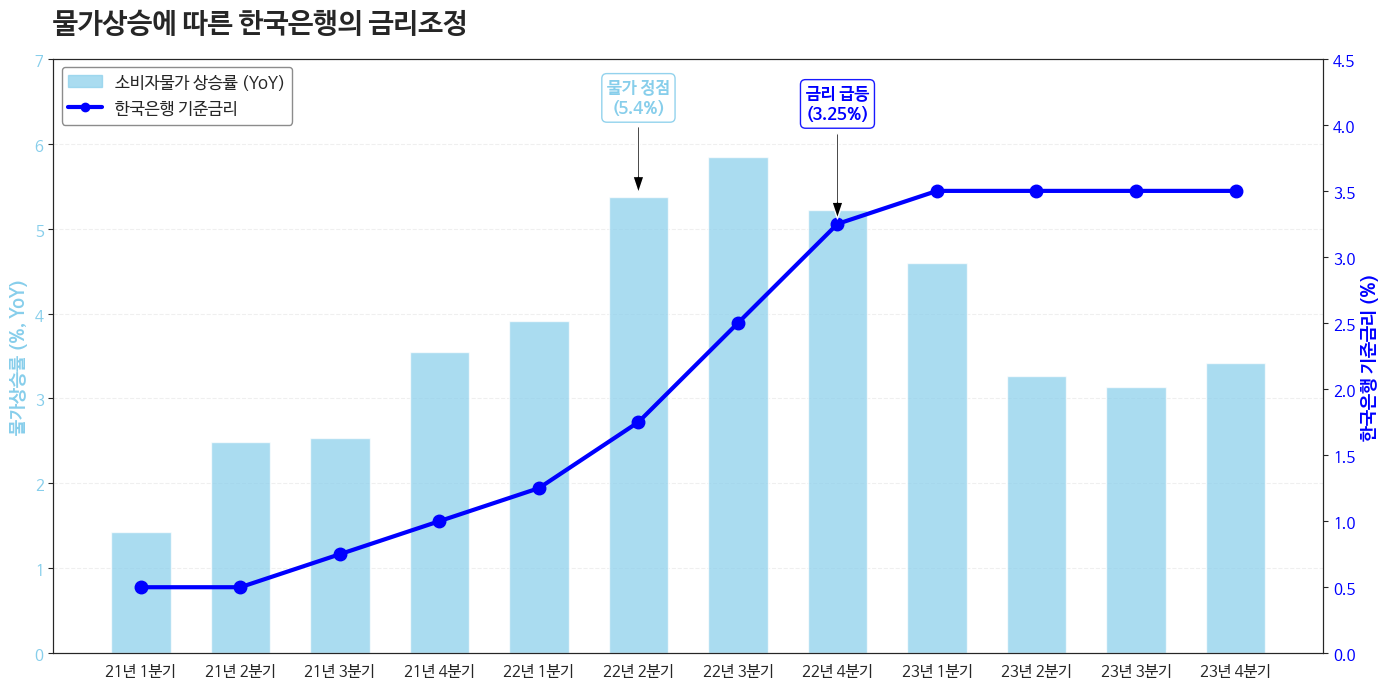

In [ ]:
import sys
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import seaborn as sns

warnings.filterwarnings("ignore")

# =======================================================
# [핵심 해결책] 폰트 강제 주입 (시스템 캐시 무시)
# =======================================================
def set_font_force():
    # 폰트 파일 경로 직접 지정
    path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    if os.path.exists(path):
        # 1. 폰트 매니저에 경로 강제 등록
        fm.fontManager.addfont(path)

        # 2. 폰트 이름 가져오기
        font_name = fm.FontProperties(fname=path).get_name()

        # 3. Seaborn 스타일 설정 먼저 실행 (순서 중요!)
        sns.set_style("white")

        # 4. 그 다음 폰트 설정 덮어쓰기
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지
        print(f"한글 폰트 설정 완료: {font_name}")
    else:
        print("폰트 파일이 없습니다. 1단계 설치를 확인해주세요.")

set_font_force()

# =======================================================
# 데이터 로딩 및 그래프 그리기
# =======================================================
file_paths = {'base_rate': 'base_rate.csv', 'cpi': 'cpi.csv'}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]
    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    return df_val

def draw_final_chart_fixed():
    df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
    df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')

    if df_base is None or df_cpi is None:
        print("데이터 파일이 없습니다.")
        return

    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')
    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)

    df_macro['CPI_YoY'] = df_macro['CPI'].pct_change(4) * 100
    df_plot = df_macro[(df_macro['Year'] >= 2021) & (df_macro['Year'] <= 2023)].copy()
    df_plot['Date_Ko'] = df_plot['Date'].apply(lambda x: f"{x.split('/')[0][2:]}년 {x.split('/')[1].replace('Q', '')}분기")

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # 1. 물가상승률 (Bar Chart) - 하늘색
    ax1.bar(df_plot['Date_Ko'], df_plot['CPI_YoY'], color='skyblue', alpha=0.7, width=0.6, zorder=1)
    ax1.set_ylabel('물가상승률 (%, YoY)', color='skyblue', fontsize=13, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='skyblue', labelsize=11)
    ax1.tick_params(axis='x', labelsize=11, rotation=0)
    ax1.set_ylim(0, 7)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # 2. 기준금리 (Line Chart) - 파란색
    ax2 = ax1.twinx()
    ax2.plot(df_plot['Date_Ko'], df_plot['Base_Rate'], color='blue', marker='o', markersize=9, linewidth=3, zorder=2)
    ax2.set_ylabel('한국은행 기준금리 (%)', color='blue', fontsize=13, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=11)
    ax2.set_ylim(0, 4.5)

    plt.title('물가상승에 따른 한국은행의 금리조정', fontsize=20, fontweight='bold', loc='left', pad=20)

    # 주석
    if '22년 2분기' in df_plot['Date_Ko'].values:
        peak_idx = list(df_plot['Date_Ko']).index('22년 2분기')
        peak_val = df_plot[df_plot['Date_Ko'] == '22년 2분기']['CPI_YoY'].values[0]
        ax1.annotate(f'물가 정점\n({peak_val:.1f}%)', xy=(peak_idx, peak_val), xytext=(peak_idx, peak_val + 1.0),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     ha='center', color='skyblue', fontweight='bold', fontsize=12,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="skyblue", alpha=0.9))

    if '22년 4분기' in df_plot['Date_Ko'].values:
        hike_idx = list(df_plot['Date_Ko']).index('22년 4분기')
        hike_val = df_plot[df_plot['Date_Ko'] == '22년 4분기']['Base_Rate'].values[0]
        ax2.annotate(f'금리 급등\n({hike_val}%)', xy=(hike_idx, hike_val), xytext=(hike_idx, hike_val + 0.8),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     ha='center', color='blue', fontweight='bold', fontsize=12,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.9))

    legend_elements = [
        mpatches.Patch(color='skyblue', alpha=0.7, label='소비자물가 상승률 (YoY)'),
        plt.Line2D([0], [0], color='blue', lw=3, marker='o', label='한국은행 기준금리')
    ]
    ax1.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True, framealpha=0.9, edgecolor='gray')

    plt.tight_layout()
    plt.show()

draw_final_chart_fixed()

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

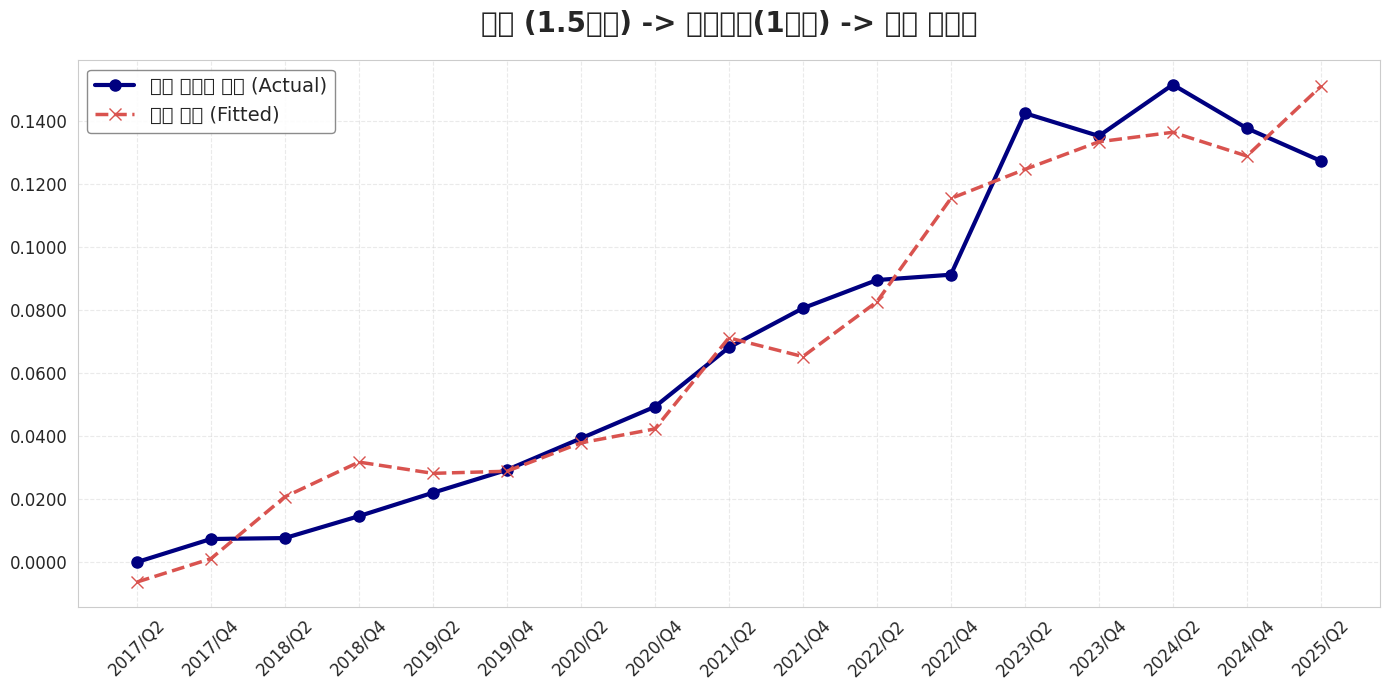

In [ ]:
import sys
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns

warnings.filterwarnings("ignore")

# === 폰트 설정 (깨짐 방지) ===
def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False
    else:
        print("폰트 파일 없음. 1단계 실행 확인 필요.")

set_korean_font()

# === 데이터 로딩 및 전처리 ===
file_paths = {
    'base_rate': 'base_rate.csv', 'cpi': 'cpi.csv', 'bond': 'bond.csv',
    'capital': 'capital.csv', 'dividend': 'dividend2.csv'
}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]
    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    return df_val

def draw_perfect_chart():
    # 데이터 로드
    df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
    df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')
    df_bond = preprocess_macro(read_csv_safe(file_paths['bond']), 'Bond_Yield')
    df_div = read_csv_safe(file_paths['dividend'])
    df_capital = read_csv_safe(file_paths['capital'])

    if not all(v is not None for v in [df_base, df_cpi, df_bond, df_div, df_capital]):
        return

    # 매크로 처리
    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')
    df_macro = pd.merge(df_macro, df_bond, on='Date', how='inner')
    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)

    df_macro['CPI_Lag4'] = df_macro['CPI'].shift(4)
    df_macro['Exp_Inflation'] = (df_macro['CPI'] - df_macro['CPI_Lag4']) / df_macro['CPI_Lag4'] * 100

    df_macro_semi = df_macro[df_macro['Quarter'].isin([2, 4])].copy()
    df_macro_semi['CPI_Lag_18M'] = df_macro_semi['CPI'].shift(3)
    df_macro_semi['Base_Rate_Lag_1Y'] = df_macro_semi['Base_Rate'].shift(2)
    df_macro_semi['Bond_Yield_Lag_1Y'] = df_macro_semi['Bond_Yield'].shift(2)
    df_macro_semi['Exp_Inflation_Lag_18M'] = df_macro_semi['Exp_Inflation'].shift(3)
    df_macro_semi['Semi_Year_Match'] = df_macro_semi['Quarter'].apply(lambda x: 1 if x==2 else 2)

    # 배당/자본금 처리
    df_div.columns = df_div.columns.str.strip()
    df_div['dividend'] = pd.to_numeric(df_div['dividend'].astype(str).str.replace(',', ''), errors='coerce')
    df_div['semi-year'] = df_div['month'].apply(lambda x: 1 if x <= 6 else 2)
    market_div = df_div.groupby(['year', 'semi-year'])['dividend'].sum().reset_index()
    market_div.rename(columns={'year': 'Year', 'semi-year': 'Semi_Year'}, inplace=True)

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']], on=['Year', 'Semi_Year'], how='inner')
    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']

    # 최종 병합 & 회귀분석
    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['Year', 'Semi_Year'], right_on=['Year', 'Semi_Year_Match'], how='inner')
    df_reg = df_final.dropna().reset_index(drop=True)

    if len(df_reg) < 5: return

    X_cols = ['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Bond_Yield_Lag_1Y', 'Exp_Inflation_Lag_18M']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    # === [디자인 수정된 그래프] ===
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid") # 깔끔한 격자 배경

    # 1. 실제값 (Actual) - 진한 파랑, 굵은 선, 큰 점
    plt.plot(df_reg['Date'], y, label='실제 배당액 비율 (Actual)',
             marker='o', markersize=8, linewidth=3, color='#000080') # Navy Color

    # 2. 예측값 (Fitted) - 진한 빨강, 점선
    plt.plot(df_reg['Date'], model.predict(X), label='예측 모델 (Fitted)',
             linestyle='--', linewidth=2.5, marker='x', markersize=8, color='#D9534F') # Crimson Color

    # 3. 제목 (사용자 요청 문구 그대로)
    plt.title('물가 (1.5년전) -> 금리상승(1년전) -> 현재 배당액', fontsize=20, fontweight='bold', pad=20)

    # 4. 축 및 범례 설정
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=14, loc='upper left', frameon=True, framealpha=0.9, edgecolor='gray')
    plt.grid(True, alpha=0.4, linestyle='--')

    # Y축 소수점 포맷
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    plt.tight_layout()
    plt.show()

draw_perfect_chart()

In [ ]:
# 배당은 증가했는데 리츠의 시세차익+ 배당액 vs 채권의 가격변동+ 배당액 수익률 비교 -> ㅅㅂ 채권 압승.
# 일단 여기까지 분석 후 흥미로운 척 한 뒤에 실제 포트폴리오에 넘겨서 최종 결론 내는식으로 가야될듯..

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

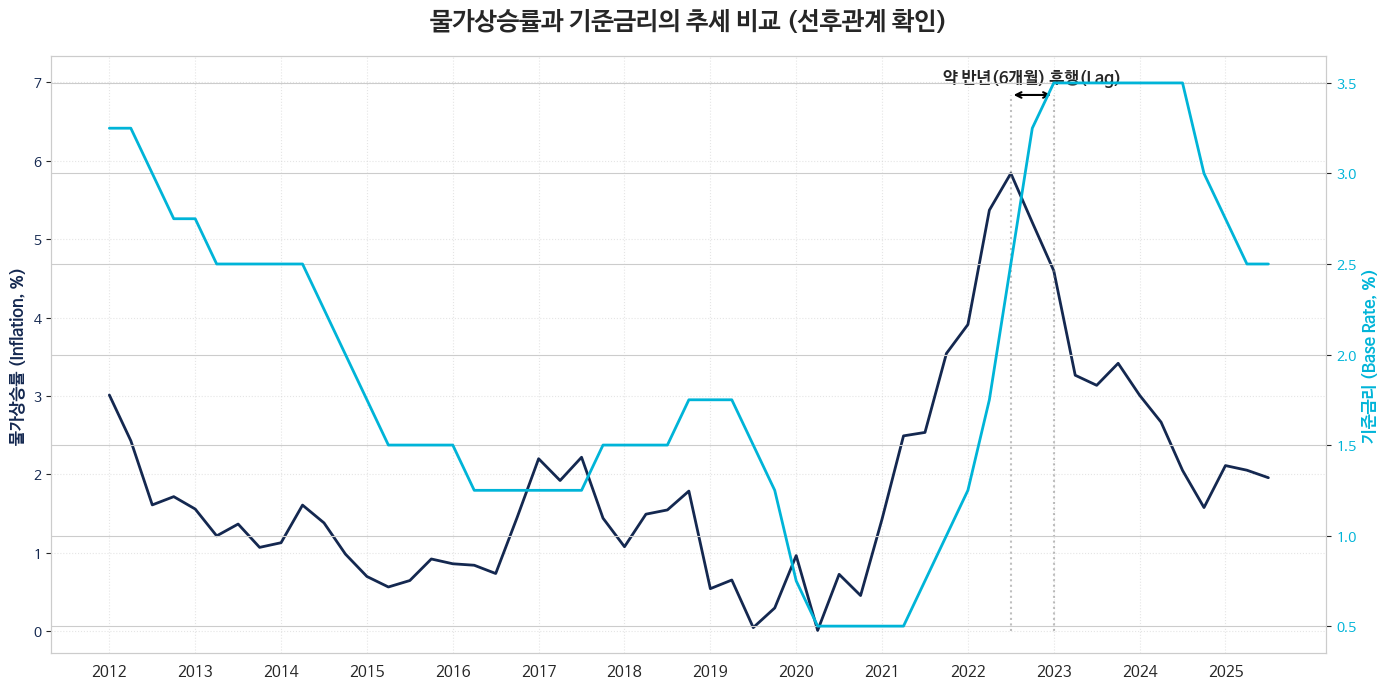

In [ ]:
# 1. 폰트 및 라이브러리 설정 (기존과 동일)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import warnings

# ==============================================================================
# 1. 폰트 설정
# ==============================================================================
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")

# ==============================================================================
# 2. 데이터 불러오기 및 전처리 (기존 로직 유지)
# ==============================================================================
def preprocess_macro_quarterly(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]

    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)

    df_val['Year'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_val['Quarter'] = df_val['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_val = df_val.sort_values(['Year', 'Quarter']).reset_index(drop=True)
    return df_val

try:
    df_base = preprocess_macro_quarterly(pd.read_csv('base_rate.csv', encoding='utf-8'), 'Base_Rate')
    df_cpi = preprocess_macro_quarterly(pd.read_csv('cpi.csv', encoding='utf-8'), 'CPI')
except:
    df_base = preprocess_macro_quarterly(pd.read_csv('base_rate.csv', encoding='cp949'), 'Base_Rate')
    df_cpi = preprocess_macro_quarterly(pd.read_csv('cpi.csv', encoding='cp949'), 'CPI')

if df_base is not None and df_cpi is not None:
    df = pd.merge(df_base, df_cpi, on=['Date', 'Year', 'Quarter'], how='inner')
    df['Inflation'] = df['CPI'].pct_change(4) * 100
    df_clean = df.dropna().reset_index(drop=True)

    # ==============================================================================
    # 3. 그래프 그리기 (수정된 부분)
    # ==============================================================================
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # (1) 물가상승률 -> [수정] 진한 남색 (Dark Navy)
    color_1 = '#142850' # 진한 남색 Hex Code
    ax1.set_ylabel('물가상승률 (Inflation, %)', color=color_1, fontweight='bold', fontsize=12)
    ax1.plot(df_clean.index, df_clean['Inflation'], color=color_1, linewidth=2, label='물가상승률')
    ax1.tick_params(axis='y', labelcolor=color_1)

    # (2) 기준금리 -> [수정] 하늘색 (Sky Blue) & 실선(Solid)
    ax2 = ax1.twinx()
    color_2 = '#00B4D8' # 선명한 하늘색 Hex Code
    ax2.set_ylabel('기준금리 (Base Rate, %)', color=color_2, fontweight='bold', fontsize=12)
    # linestyle='--'를 삭제하거나 '-'로 변경하여 실선으로 만듦
    ax2.plot(df_clean.index, df_clean['Base_Rate'], color=color_2, linestyle='-', linewidth=2, label='기준금리')
    ax2.tick_params(axis='y', labelcolor=color_2)

    # (3) X축 설정 (기존 동일)
    tick_idxs = np.arange(0, len(df_clean), 4)
    tick_labels = [str(df_clean['Date'][i]).split('/')[0] for i in tick_idxs]

    ax1.set_xticks(tick_idxs)
    ax1.set_xticklabels(tick_labels, rotation=0, fontsize=11)
    ax1.set_xlabel('')

    # (4) 화살표 및 텍스트 (기존 동일)
    try:
        mask_2022 = df_clean['Date'].astype(str).str.contains('2022')
        if mask_2022.any():
            idx_inf_peak = df_clean.loc[mask_2022, 'Inflation'].idxmax()
            idx_rate_peak = idx_inf_peak + 2

            y_limit = max(df_clean['Inflation'].max(), df_clean['Base_Rate'].max()) + 1.5
            ax1.set_ylim(top=y_limit)

            arrow_y = y_limit - 0.5

            ax1.annotate('',
                         xy=(idx_inf_peak, arrow_y),
                         xytext=(idx_rate_peak, arrow_y),
                         arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))

            ax1.text((idx_inf_peak + idx_rate_peak)/2, arrow_y + 0.1, "약 반년(6개월) 후행(Lag)",
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

            ax1.vlines([idx_inf_peak, idx_rate_peak], 0, arrow_y, color='gray', linestyle=':', alpha=0.5)

    except Exception as e:
        print("화살표 표시 실패:", e)

    # 제목 및 그리드
    plt.title('물가상승률과 기준금리의 추세 비교 (선후관계 확인)', fontsize=18, fontweight='bold', pad=20)
    ax1.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("CSV 파일이 없습니다. base_rate.csv, cpi.csv 파일을 업로드해주세요.")

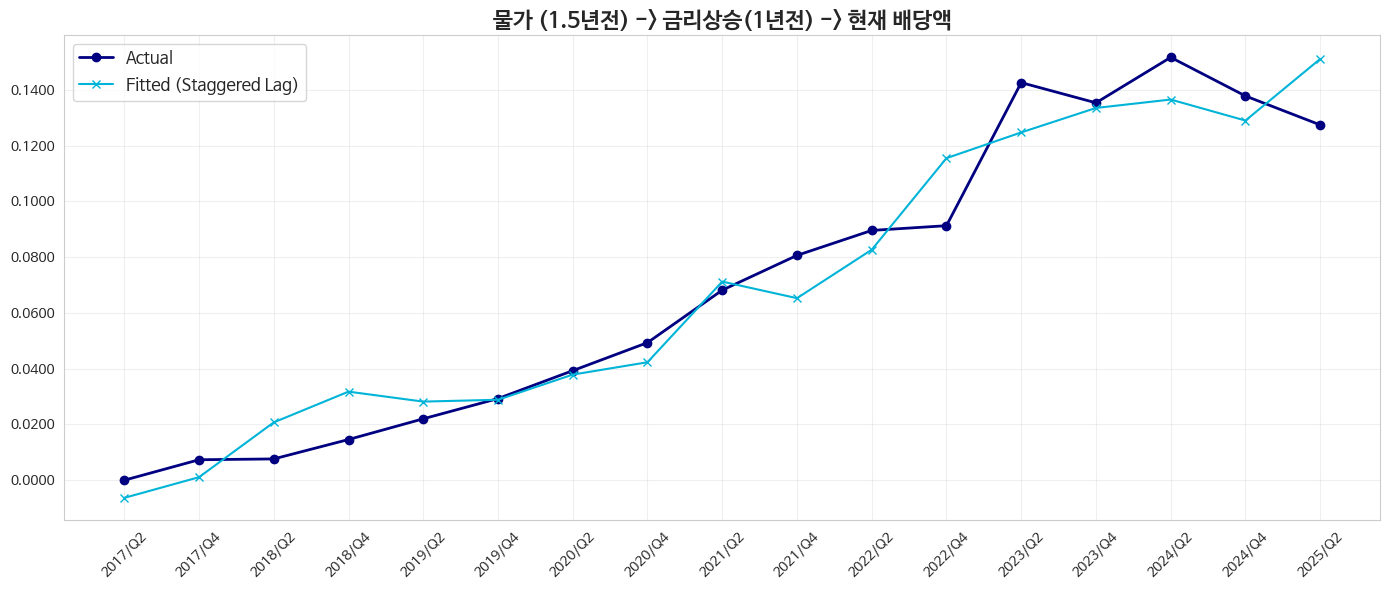

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import matplotlib.ticker as ticker

# ==============================================================================
# [수정됨] 딱 이 그래프 하나만 그리는 코드 (하늘색 실선 적용)
# ==============================================================================
def run_staggered_model_only_fit():
    # 1. 데이터 준비 (기존 로직 동일)
    # (주의: 이 함수를 실행하기 전에 file_paths, market_div, df_macro_semi, read_csv_safe 등이 정의되어 있어야 합니다)
    try:
        df_capital = read_csv_safe(file_paths['capital'])
    except NameError:
        print("필요한 데이터 변수나 함수(read_csv_safe 등)가 정의되지 않았습니다. 이전 셀들을 먼저 실행해주세요.")
        return

    if df_capital is None or market_div is None or df_macro_semi is None:
        return

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']],
                      left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year'], how='inner')

    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']

    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year_Match'], how='inner')
    df_reg = df_final.dropna().reset_index(drop=True)

    if len(df_reg) < 5: return

    # 2. 회귀분석 수행
    X_cols = ['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Bond_Yield_Lag_1Y', 'Exp_Inflation_Lag_18M']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    # ==========================================================================
    # 3. [요청하신 부분] 그래프 그리기 (하늘색 실선 수정됨)
    # ==========================================================================
    plt.figure(figsize=(14, 6))

    # 실제값 (기존 유지: 남색 실선)
    plt.plot(df_reg['Date'], y, label='Actual', marker='o', linewidth=2, color='navy')

    # 예측값 -> [수정] 하늘색(#00B4D8) & 실선('-')
    plt.plot(df_reg['Date'], model.predict(X), label='Fitted (Staggered Lag)',
             linestyle='-', marker='x', color='#00B4D8')

    # 타이틀 및 설정 (기존 유지)
    plt.title('물가 (1.5년전) -> 금리상승(1년전) -> 현재 배당액', fontsize=16, fontweight='bold')

    plt.xticks(rotation=45)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    plt.tight_layout()
    plt.show()

# 실행
run_staggered_model_only_fit()


 [최종 검증] 2022년 하반기 시나리오 적용
 변수: 물가상승률(YoY %), 기준금리(%)

[회귀분석 결과]
                            OLS Regression Results                            
Dep. Variable:         Div_to_Capital   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     7.116
Date:                Sun, 23 Nov 2025   Prob (F-statistic):            0.00738
Time:                        11:57:36   Log-Likelihood:                 32.062
No. Observations:                  17   AIC:                            -58.12
Df Residuals:                      14   BIC:                            -55.62
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

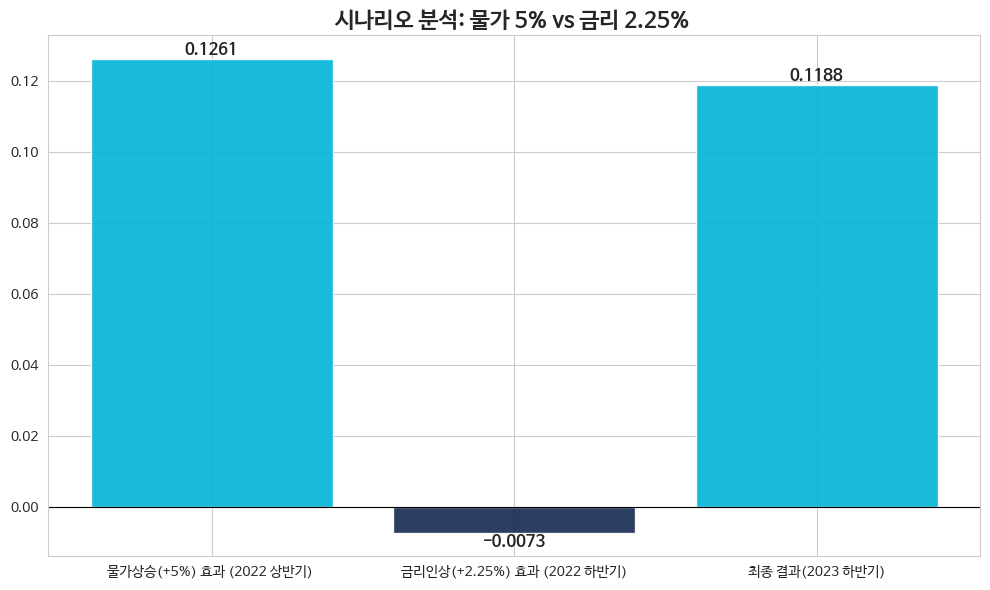

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import os
import warnings
import matplotlib.font_manager as fm

# ==============================================================================
# 1. 폰트 및 기본 설정
# ==============================================================================
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4f}'.format

def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# ==============================================================================
# 2. 데이터 유틸리티 함수
# ==============================================================================
file_paths = {
    'base_rate': 'base_rate.csv',
    'cpi': 'cpi.csv',
    'bond': 'bond.csv',
    'capital': 'capital.csv',
    'dividend': 'dividend2.csv' # 파일명이 dividend2.csv 인지 확인 필요
}

def read_csv_safe(path):
    if not os.path.exists(path): return None
    try: return pd.read_csv(path, encoding='utf-8')
    except:
        try: return pd.read_csv(path, encoding='cp949')
        except: return pd.read_csv(path, encoding='euc-kr')

def preprocess_macro(df, col_name):
    if df is None: return None
    if len([c for c in df.columns if '/Q' in str(c)]) > 2:
        valid_cols = [c for c in df.columns if '/Q' in str(c)]
        df_val = df[valid_cols].iloc[0:1].T.reset_index()
        df_val.columns = ['Date', 'Value']
    else:
        start_idx = 0
        for i in range(min(10, len(df))):
            if any('/Q' in str(val) for val in df.iloc[i].values):
                start_idx = i; break
        df_val = df.iloc[start_idx:, :2].copy()
        df_val.columns = ['Date', 'Value']
        df_val = df_val[df_val['Date'].astype(str).str.contains('/Q', na=False)]
    df_val['Value'] = pd.to_numeric(df_val['Value'], errors='coerce')
    df_val.rename(columns={'Value': col_name}, inplace=True)
    return df_val

# ==============================================================================
# 3. 메인 분석 실행 (색상 변경됨)
# ==============================================================================
def run_final_scenario_analysis():
    print(f"\n{'='*60}")
    print(f" [최종 검증] 2022년 하반기 시나리오 적용")
    print(f" 변수: 물가상승률(YoY %), 기준금리(%)")
    print(f"{'='*60}")

    # 데이터 로드
    df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
    df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')
    df_bond = preprocess_macro(read_csv_safe(file_paths['bond']), 'Bond_Yield')
    df_div = read_csv_safe(file_paths['dividend'])
    df_capital = read_csv_safe(file_paths['capital'])

    if not all(v is not None for v in [df_base, df_cpi, df_bond, df_div, df_capital]):
        print("파일 누락: 필요한 CSV 파일이 모두 있는지 확인해주세요.")
        return

    # 매크로 병합 및 물가상승률 계산
    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')
    df_macro = pd.merge(df_macro, df_bond, on='Date', how='inner')
    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)

    # [핵심] 전년 동기 대비 물가상승률 계산
    df_macro['Inflation_Rate_YoY'] = df_macro['CPI'].pct_change(4) * 100

    # 반기 데이터 필터링 및 시차 적용
    df_macro_semi = df_macro[df_macro['Quarter'].isin([2, 4])].copy()
    df_macro_semi['Inflation_Lag_18M'] = df_macro_semi['Inflation_Rate_YoY'].shift(3)
    df_macro_semi['Rate_Lag_1Y'] = df_macro_semi['Base_Rate'].shift(2)
    df_macro_semi['Semi_Year_Match'] = df_macro_semi['Quarter'].apply(lambda x: 1 if x==2 else 2)

    # 배당 및 자본금 처리
    df_div.columns = df_div.columns.str.strip()
    df_div['dividend'] = pd.to_numeric(df_div['dividend'].astype(str).str.replace(',', ''), errors='coerce')
    df_div['semi-year'] = df_div['month'].apply(lambda x: 1 if x <= 6 else 2)
    market_div = df_div.groupby(['year', 'semi-year'])['dividend'].sum().reset_index()
    market_div.rename(columns={'year': 'Year', 'semi-year': 'Semi_Year'}, inplace=True)

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']], on=['Year', 'Semi_Year'], how='inner')
    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']

    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['Year', 'Semi_Year'], right_on=['Year', 'Semi_Year_Match'], how='inner')
    df_reg = df_final.dropna().reset_index(drop=True)

    # 회귀분석 실행
    X_cols = ['Inflation_Lag_18M', 'Rate_Lag_1Y']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    print("\n[회귀분석 결과]")
    print(model.summary())

    # 시나리오 시뮬레이션
    beta_infl = model.params['Inflation_Lag_18M']
    beta_rate = model.params['Rate_Lag_1Y']

    delta_infl = 5.0   # 물가상승률 +5%p
    delta_rate = 2.25  # 금리 +2.25%p

    effect_infl = beta_infl * delta_infl
    effect_rate = beta_rate * delta_rate
    net_effect = effect_infl + effect_rate

    print(f"\n[시나리오: 물가 +5%p vs 금리 +2.25%p]")
    print(f"1. 물가상승 효과: 배당률 {effect_infl:.4f} 상승 (▲)")
    print(f"2. 금리인상 타격: 배당률 {effect_rate:.4f} 하락 (▼)")
    print("-" * 40)
    print(f"3. 최종 결과 (Net): {net_effect:.4f}")

    if net_effect > 0:
        print(f"\n>>> [최종 결론] 리츠 승리! (배당률 {net_effect*100:.2f}%p 상승)")
    else:
        print("\n>>> [최종 결론] 리츠 패배")

    # ==============================================================================
    # [수정됨] 시각화 (하늘색 & 진한 남색)
    # ==============================================================================
    plt.figure(figsize=(10, 6))

    effects = [effect_infl, effect_rate, net_effect]
    labels = ['물가상승(+5%) 효과 (2022 상반기) ', '금리인상(+2.25%) 효과 (2022 하반기)', '최종 결과(2023 하반기)']

    # [색상 변경]
    # 1. 물가(긍정) -> 하늘색 (#00B4D8)
    # 2. 금리(부정) -> 진한 남색 (#142850)
    # 3. 결과(긍정) -> 하늘색 (#00B4D8)
    colors = ['#00B4D8', '#142850', '#00B4D8']

    bar_plot = plt.bar(labels, effects, color=colors, alpha=0.9)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title('시나리오 분석: 물가 5% vs 금리 2.25% ', fontsize=16, fontweight='bold')

    for rect in bar_plot:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2.0, height, f'{height:.4f}',
                 ha='center', va='bottom' if height>0 else 'top', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()

# 실행
run_final_scenario_analysis()

                            OLS Regression Results                            
Dep. Variable:         Div_to_Capital   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     48.23
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           2.68e-07
Time:                        12:04:28   Log-Likelihood:                 50.221
No. Observations:                  17   AIC:                            -90.44
Df Residuals:                      12   BIC:                            -86.28
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.07

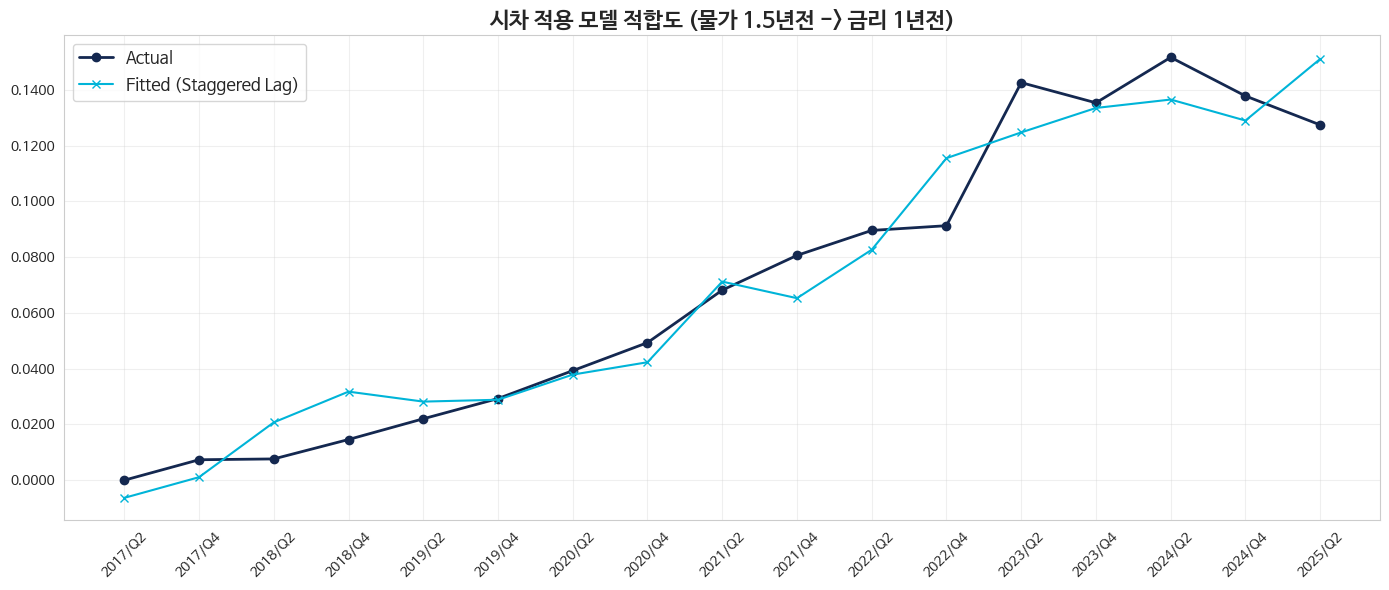

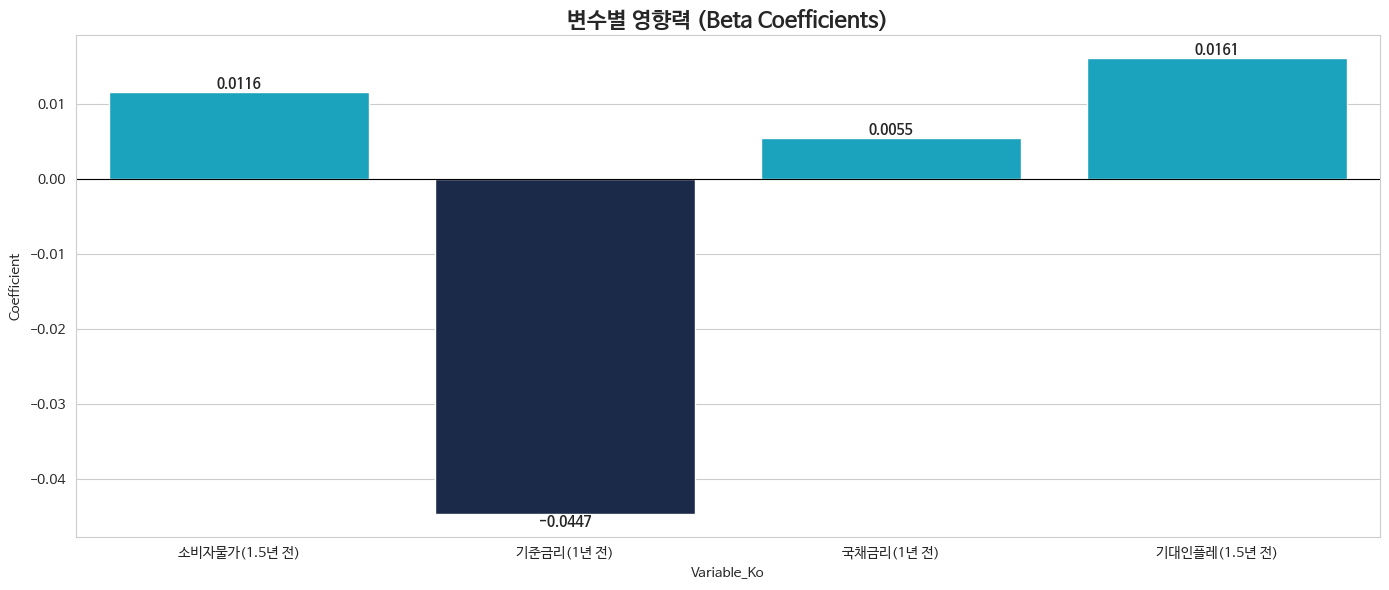

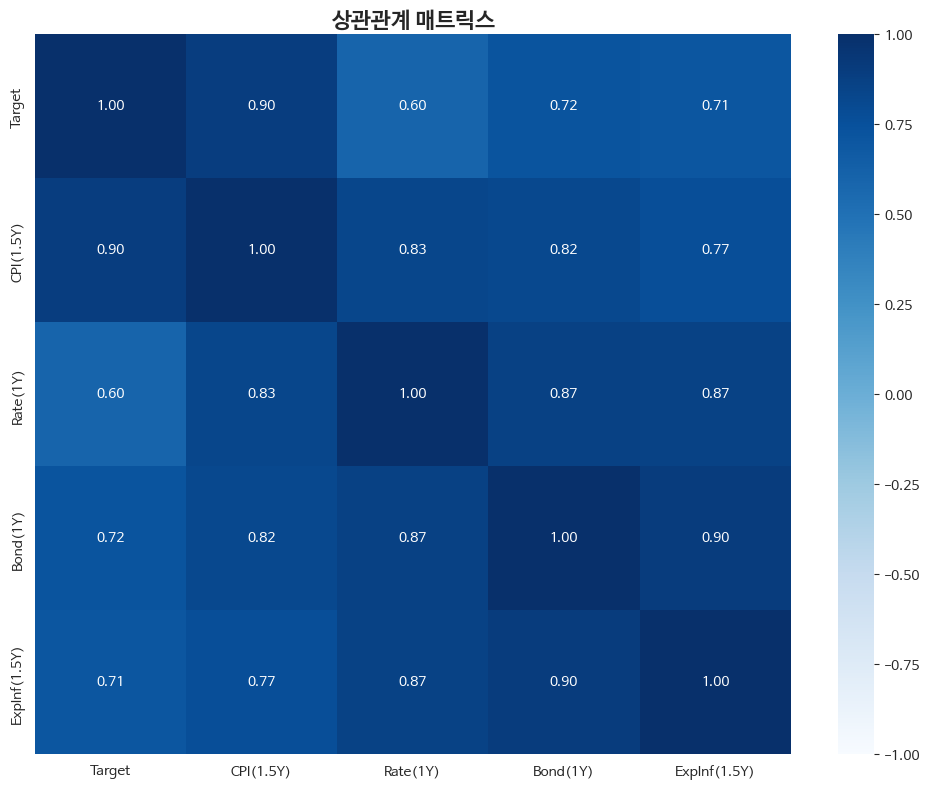


[SEM 결과 요약]
        lval  op       rval  Estimate  p-value
0  Past_Rate   ~   Past_CPI    0.8295   0.0000
1     Target   ~   Past_CPI    1.2827   0.0000
2     Target   ~  Past_Rate   -0.4659   0.0028
3  Past_Rate  ~~  Past_Rate    0.2936   0.0036
4     Target  ~~     Target    0.1211   0.0036


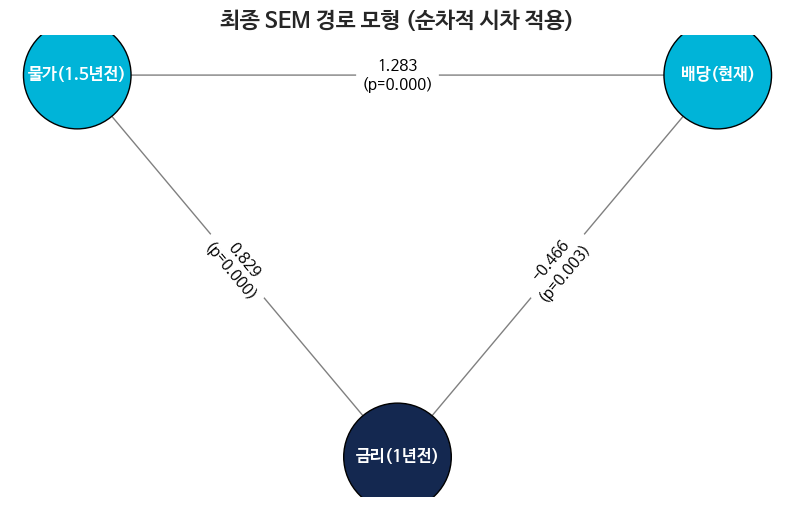


1. 직접 효과: 1.2827
2. 간접 효과: -0.3864
3. 총 효과: 0.8963


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import networkx as nx
import matplotlib.ticker as ticker
import sys
import subprocess
import os
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. 라이브러리 및 폰트 설정 (기존 유지)
# ==============================================================================
def install_and_import(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    except:
        pass

try:
    import semopy
except ImportError:
    install_and_import('semopy')
    import semopy

def set_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# ==============================================================================
# 2. 데이터 로딩 및 전처리 (기존 유지)
# ==============================================================================
# (주의: file_paths, read_csv_safe, preprocess_macro 함수들이 정의되어 있어야 합니다)
# 만약 정의되어 있지 않다면 이전 셀을 실행하거나 아래 주석을 해제하세요.
# file_paths = {'base_rate': 'base_rate.csv', 'cpi': 'cpi.csv', 'bond': 'bond.csv', 'capital': 'capital.csv', 'dividend': 'dividend2.csv'}

# 데이터 로드 로직 재확인 (이전 단계에서 이미 로드되었다면 생략 가능하지만 안전을 위해 포함)
try:
    df_base = preprocess_macro(read_csv_safe(file_paths['base_rate']), 'Base_Rate')
    df_cpi = preprocess_macro(read_csv_safe(file_paths['cpi']), 'CPI')
    df_bond = preprocess_macro(read_csv_safe(file_paths['bond']), 'Bond_Yield')
    df_div = read_csv_safe(file_paths['dividend'])
    df_capital = read_csv_safe(file_paths['capital'])
except NameError:
    print("필요한 함수(preprocess_macro 등)가 정의되지 않았습니다. 이전 코드 셀을 먼저 실행해주세요.")

# 데이터 가공 (Lag 생성 등)
if all(v is not None for v in [df_base, df_cpi, df_bond, df_div]):
    df_macro = pd.merge(df_base, df_cpi, on='Date', how='inner')
    df_macro = pd.merge(df_macro, df_bond, on='Date', how='inner')
    df_macro['Year'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[0]))
    df_macro['Quarter'] = df_macro['Date'].apply(lambda x: int(str(x).split('/')[1].replace('Q', '')))
    df_macro.sort_values(['Year', 'Quarter'], inplace=True)
    df_macro['CPI_Lag4'] = df_macro['CPI'].shift(4)
    df_macro['Exp_Inflation'] = (df_macro['CPI'] - df_macro['CPI_Lag4']) / df_macro['CPI_Lag4'] * 100

    df_macro_semi = df_macro[df_macro['Quarter'].isin([2, 4])].copy()
    df_macro_semi['CPI_Lag_18M'] = df_macro_semi['CPI'].shift(3)
    df_macro_semi['Base_Rate_Lag_1Y'] = df_macro_semi['Base_Rate'].shift(2)
    df_macro_semi['Bond_Yield_Lag_1Y'] = df_macro_semi['Bond_Yield'].shift(2)
    df_macro_semi['Exp_Inflation_Lag_18M'] = df_macro_semi['Exp_Inflation'].shift(3)
    df_macro_semi['Semi_Year_Match'] = df_macro_semi['Quarter'].apply(lambda x: 1 if x==2 else 2)

    df_div.columns = df_div.columns.str.strip()
    if 'dividend' in df_div.columns:
        df_div['dividend'] = df_div['dividend'].astype(str).str.replace(',', '')
        df_div['dividend'] = pd.to_numeric(df_div['dividend'], errors='coerce')
        df_div['semi-year'] = df_div['month'].apply(lambda x: 1 if x <= 6 else 2)
        market_div = df_div.groupby(['year', 'semi-year'])['dividend'].sum().reset_index()

# ==============================================================================
# 3. 모델 실행 및 시각화 (색상 수정 완료)
# ==============================================================================
def run_staggered_model():
    # 데이터 준비
    if df_capital is None or market_div is None or df_macro_semi is None:
        print("필요한 데이터가 로드되지 않았습니다.")
        return

    market_capital = df_capital.iloc[:, 1:].sum(axis=0).reset_index()
    market_capital.columns = ['Date_Raw', 'Total_Capital']
    market_capital['Total_Capital'] = pd.to_numeric(market_capital['Total_Capital'], errors='coerce')
    market_capital['Date_Obj'] = pd.to_datetime(market_capital['Date_Raw'], format='%Y%m%d', errors='coerce')
    market_capital['Year'] = market_capital['Date_Obj'].dt.year
    market_capital['Semi_Year'] = market_capital['Date_Obj'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

    df_ratio = pd.merge(market_div, market_capital[['Year', 'Semi_Year', 'Total_Capital']],
                      left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year'], how='inner')

    df_ratio['Div_to_Capital'] = df_ratio['dividend'] / df_ratio['Total_Capital']
    df_final = pd.merge(df_ratio, df_macro_semi, left_on=['year', 'semi-year'], right_on=['Year', 'Semi_Year_Match'], how='inner')
    df_reg = df_final.dropna().reset_index(drop=True)

    if len(df_reg) < 5: return

    # OLS 회귀분석
    X_cols = ['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Bond_Yield_Lag_1Y', 'Exp_Inflation_Lag_18M']
    X = df_reg[X_cols]
    y = df_reg['Div_to_Capital']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    print(model.summary())

    coef_df = pd.DataFrame({'Variable': X.columns[1:], 'Coefficient': model.params[1:]})
    name_mapping = {
        'CPI_Lag_18M': '소비자물가(1.5년 전)',
        'Base_Rate_Lag_1Y': '기준금리(1년 전)',
        'Bond_Yield_Lag_1Y': '국채금리(1년 전)',
        'Exp_Inflation_Lag_18M': '기대인플레(1.5년 전)'
    }
    coef_df['Variable_Ko'] = coef_df['Variable'].map(name_mapping)

    # [색상 코드 정의]
    COLOR_SKY = '#00B4D8'   # 하늘색
    COLOR_NAVY = '#142850'  # 진한 남색

    # --------------------------------------------------------------------------
    # 그래프 1: 시차 적용 모델 적합도 (Actual=남색, Fitted=하늘색)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(14, 6))
    plt.plot(df_reg['Date'], y, label='Actual', marker='o', linewidth=2, color=COLOR_NAVY)
    plt.plot(df_reg['Date'], model.predict(X), label='Fitted (Staggered Lag)', linestyle='-', marker='x', color=COLOR_SKY)
    plt.title('시차 적용 모델 적합도 (물가 1.5년전 -> 금리 1년전)', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 그래프 2: 변수별 영향력 (양수=하늘색, 음수=남색)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(14, 6))
    # 양수(Positive) -> 하늘색, 음수(Negative) -> 남색
    bar_colors = [COLOR_SKY if x > 0 else COLOR_NAVY for x in coef_df['Coefficient']]

    bar_plot = sns.barplot(x='Variable_Ko', y='Coefficient', data=coef_df, palette=bar_colors)
    plt.title('변수별 영향력 (Beta Coefficients)', fontsize=16, fontweight='bold')
    plt.axhline(0, color='black', linewidth=0.8)

    for p in bar_plot.patches:
        val = p.get_height()
        plt.text(p.get_x() + p.get_width()/2, val, f'{val:.4f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 그래프 3: 상관관계 매트릭스 (Blues 테마)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(10, 8))
    corr_cols = ['Div_to_Capital'] + X_cols
    corr_data = df_reg[corr_cols].copy()
    corr_data.columns = ['Target', 'CPI(1.5Y)', 'Rate(1Y)', 'Bond(1Y)', 'ExpInf(1.5Y)']

    # 테마에 맞춰 Blues 사용 (진한 파랑 = 높은 상관관계)
    sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1)
    plt.title('상관관계 매트릭스', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 그래프 4: SEM 경로 모형 (노드 색상 변경)
    # --------------------------------------------------------------------------
    df_sem = df_reg[['CPI_Lag_18M', 'Base_Rate_Lag_1Y', 'Div_to_Capital']].copy()
    df_sem.columns = ['Past_CPI', 'Past_Rate', 'Target']
    df_sem = (df_sem - df_sem.mean()) / df_sem.std()

    desc = """
    Past_Rate ~ Past_CPI
    Target ~ Past_CPI + Past_Rate
    """
    try:
        model_sem = semopy.Model(desc)
        result_sem = model_sem.fit(df_sem)
        estimates = model_sem.inspect()

        print("\n[SEM 결과 요약]")
        print(estimates[['lval', 'op', 'rval', 'Estimate', 'p-value']].to_string(float_format=lambda x: "{:.4f}".format(x)))

        plt.figure(figsize=(10, 6))
        G = nx.DiGraph()
        pos = {'Past_CPI': (0, 1), 'Past_Rate': (1, 0), 'Target': (2, 1)}
        labels = {'Past_CPI': '물가(1.5년전)', 'Past_Rate': '금리(1년전)', 'Target': '배당(현재)'}

        edges = []
        edge_labels = {}
        def get_est_p(l, r):
            row = estimates[(estimates['lval']==l) & (estimates['rval']==r)]
            if len(row) > 0: return row['Estimate'].values[0], row['p-value'].values[0]
            return 0, 1

        est1, p1 = get_est_p('Past_Rate', 'Past_CPI')
        edges.append(('Past_CPI', 'Past_Rate'))
        edge_labels[('Past_CPI', 'Past_Rate')] = f"{est1:.3f}\n(p={p1:.3f})"

        est2, p2 = get_est_p('Target', 'Past_Rate')
        edges.append(('Past_Rate', 'Target'))
        edge_labels[('Past_Rate', 'Target')] = f"{est2:.3f}\n(p={p2:.3f})"

        est3, p3 = get_est_p('Target', 'Past_CPI')
        edges.append(('Past_CPI', 'Target'))
        edge_labels[('Past_CPI', 'Target')] = f"{est3:.3f}\n(p={p3:.3f})"

        G.add_edges_from(edges)

        # [색상 변경] 노드 색상: 하늘색, 남색, 하늘색
        node_colors = [COLOR_SKY, COLOR_NAVY, COLOR_SKY]

        nx.draw_networkx_nodes(G, pos, node_size=6000, node_color=node_colors, edgecolors='black')
        nx.draw_networkx_labels(G, pos, labels=labels, font_family='NanumBarunGothic', font_size=12, font_weight='bold', font_color='white') # 폰트 흰색으로 가독성 확보
        nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle='-|>', arrowsize=25, edge_color='gray')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_family='NanumBarunGothic', font_size=11)

        plt.title("최종 SEM 경로 모형 (순차적 시차 적용)", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.show()

        dir_eff = est3
        ind_eff = est1 * est2
        tot_eff = dir_eff + ind_eff
        print(f"\n1. 직접 효과: {dir_eff:.4f}")
        print(f"2. 간접 효과: {ind_eff:.4f}")
        print(f"3. 총 효과: {tot_eff:.4f}")

    except Exception as e:
        print("SEM 분석 중 오류 발생:", e)

# 실행
run_staggered_model()

In [ ]:
# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum

# 2. 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. 맷플롯립 캐시 삭제 (중요)
!rm ~/.cache/matplotlib -rf

print("★설치 완료! 이제 상단 메뉴에서 [런타임] -> [세션 다시 시작]을 꼭 누르세요!★")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

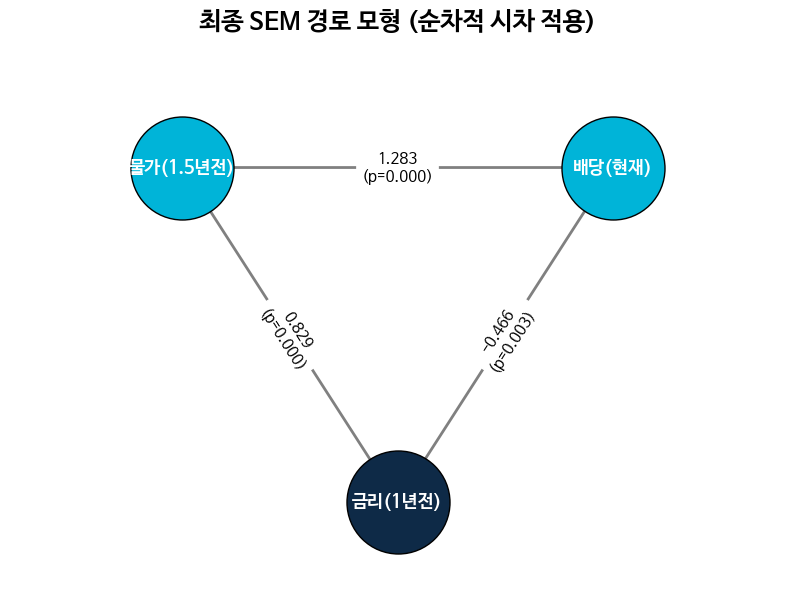

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.font_manager as fm

# 1. 코랩용 한글 폰트 설정 (NanumBarunGothic)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지

# 2. 그래프 데이터 정의
G = nx.DiGraph()
nodes = ['물가(1.5년전)', '배당(현재)', '금리(1년전)']

# 엣지 데이터 (라벨 포함)
edges = [
    ('물가(1.5년전)', '배당(현재)', '1.283\n(p=0.000)'),
    ('물가(1.5년전)', '금리(1년전)', '0.829\n(p=0.000)'),
    ('금리(1년전)', '배당(현재)', '-0.466\n(p=0.003)'),
]

G.add_nodes_from(nodes)
for u, v, label in edges:
    G.add_edge(u, v, label=label)

# 3. 위치 좌표 설정 (삼각형)
pos = {
    '물가(1.5년전)': (-1, 1),
    '배당(현재)': (1, 1),
    '금리(1년전)': (0, -0.8)
}

# 4. 그림 그리기 (잘림 방지 포함)
plt.figure(figsize=(10, 7)) # 캔버스 크기

# 노드 그리기
nx.draw_networkx_nodes(G, pos,
                       nodelist=['물가(1.5년전)', '배당(현재)'],
                       node_color='#00B4D8', # 하늘색
                       node_size=5500,       # 원 크기
                       edgecolors='black')

nx.draw_networkx_nodes(G, pos,
                       nodelist=['금리(1년전)'],
                       node_color='#0E2A47', # 남색
                       node_size=5500,
                       edgecolors='black')

# 텍스트 넣기 (굵게)
nx.draw_networkx_labels(G, pos, font_size=13, font_color='white', font_weight='bold', font_family='NanumBarunGothic')

# 화살표 그리기
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowstyle='-|>', arrowsize=30, width=2)

# 엣지 라벨 넣기 (수치)
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, label_pos=0.5, font_family='NanumBarunGothic')

# ★★★ 중요: 잘림 방지를 위한 여백 확보 ★★★
plt.xlim(-1.8, 1.8) # 좌우를 넓게
plt.ylim(-1.3, 1.6) # 위아래를 넓게

plt.axis('off') # 축 숨기기
plt.title("최종 SEM 경로 모형 (순차적 시차 적용)", fontsize=18, fontweight='bold', pad=20)

# 결과 출력
plt.show()